# Sistema LADA: Recomendaciones Académicas con Clustering Multinivel

## Descripción del Sistema

LADA es un dashboard de learning analytics diseñado para apoyar a consejeros académicos en la toma de decisiones sobre planificación de semestres estudiantiles.

### Método de Predicción

El sistema usa **clustering multinivel con niveles de especificidad adaptativos** (Fuzzy C-means). La metodología funciona así:

1. **Agrupación Histórica**: Agrupa estudiantes históricos según sus características
2. **Probabilidad de Éxito**: El porcentaje de estudiantes en cada cluster que completaron exitosamente sus cursos refleja la "probabilidad de éxito" para un nuevo estudiante similar
3. **Especificidad Adaptativa**: El sistema adapta automáticamente el nivel de especificidad según los datos disponibles:
   - **Estudiantes "mainstream"**: Se predicen mejor con modelos específicos (muchos estudiantes similares)
   - **Estudiantes "outliers"**: Se predicen mejor con modelos menos específicos que permiten agruparlos con un rango más amplio de estudiantes previos

### Atributos para el Clustering

El modelo considera dos características principales:

1. **Rendimiento estudiantil (Student performance)**: El promedio de calificaciones obtenidas en cursos previos
2. **Carga de cursos (Course load)**: El número de cursos seleccionados en relación con los créditos requeridos y la clasificación de los cursos

### Niveles Jerárquicos de Especificidad

Para el atributo de cursos, hay 3 niveles jerárquicos de especificidad:

- **Nivel 1 (Menos específico)**: Solo el número total de cursos tomados
  - Ejemplo: "todos los estudiantes que tomaron 5 cursos en el semestre"
  - **Produce clusters más grandes**

- **Nivel 2 (Especificidad media)**: Número de cursos contados según agrupación temática
  - Ejemplo: "todos los estudiantes que tomaron 2 de Matemáticas, 1 de Diseño y 2 de Educación General en el mismo semestre"
  - **Produce clusters medianos**

- **Nivel 3 (Más específico)**: Los códigos individuales de cada curso
  - Ejemplo: "todos los estudiantes que tomaron Math101, Math102, Des201, Com102 y Art103 en el mismo semestre"
  - **Produce clusters más pequeños**

### Lógica de Selección

El framework selecciona automáticamente qué nivel usar según el estudiante:
- **Estudiantes típicos ("mainstream")** → modelos más específicos (nivel 3), porque hay suficientes estudiantes similares
- **Estudiantes atípicos ("outliers")** → modelos menos específicos (nivel 1 o 2), para poder agruparlos con un rango más amplio de estudiantes históricos

---

## Referencias

Este notebook implementa la metodología descrita en el paper original de LADA adaptada a los datos institucionales disponibles.

## 1. Importación de Bibliotecas

In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.model_selection import train_test_split
import warnings
from typing import Dict, List, Tuple
from collections import defaultdict
import itertools
import skfuzzy as fuzz

warnings.filterwarnings('ignore')
plt.style.use('default')
sns.set_palette('husl')
%matplotlib inline

## 2. Carga y Preparación de Datos

Cargamos los datasets necesarios según el análisis de "Punto 6 Completo.pdf":

In [80]:
# Rutas de datos
DATA_PATH = '../data/'


# Dataset 1: Historial de materias (CRÍTICO - contiene combinaciones de cursos)
df_materias = pd.read_parquet(f'{DATA_PATH}historial_materias_estudiante_anonymized.parquet')
print(f" Historial de materias: {df_materias.shape[0]:,} registros, {df_materias.shape[1]} columnas")

# Dataset 2: Rendimiento académico (CRÍTICO - contiene calificaciones)
df_rendimiento = pd.read_parquet(f'{DATA_PATH}historial_rendimiento_academico_estudiante_anonymized.parquet')
print(f" Rendimiento académico: {df_rendimiento.shape[0]:,} registros, {df_rendimiento.shape[1]} columnas")

# Dataset 3: Percentiles académicos (IMPORTANTE - normaliza rendimiento por programa)
df_percentiles = pd.read_parquet(f'{DATA_PATH}percentiles_academicos_estudiante_anonymized.parquet')
print(f" Percentiles académicos: {df_percentiles.shape[0]:,} registros, {df_percentiles.shape[1]} columnas")

# Dataset 4: Información actual (COMPLEMENTARIO - contexto del estudiante)
df_info_actual = pd.read_parquet(f'{DATA_PATH}informacion_actual_estudiante_anonymized.parquet')
print(f" Información actual: {df_info_actual.shape[0]:,} registros, {df_info_actual.shape[1]} columnas")

# Dataset 5: Riesgos históricos (IMPORTANTE - indicadores de alerta)
df_riesgos = pd.read_parquet(f'{DATA_PATH}riesgos_historicos_estudiante_pregrado_anonymized.parquet')
print(f" Riesgos históricos: {df_riesgos.shape[0]:,} registros, {df_riesgos.shape[1]} columnas")



 Historial de materias: 4,931,740 registros, 15 columnas
 Rendimiento académico: 611,654 registros, 22 columnas
 Percentiles académicos: 158,429 registros, 11 columnas
 Información actual: 222,407 registros, 30 columnas
 Riesgos históricos: 369,370 registros, 12 columnas


In [81]:
df_materias["RESULTADO"]

0           RETIRADO
1           RETIRADO
2           APROBADO
3           APROBADO
4           APROBADO
             ...    
4931735    REPROBADO
4931736     APROBADO
4931737     APROBADO
4931738     APROBADO
4931739     APROBADO
Name: RESULTADO, Length: 4931740, dtype: object

In [78]:
df_materias.columns

Index(['PERIODO', 'CODIGO_ESTUDIANTE', 'NIVEL_ACADEMICO_ESTUDIANTE', 'CRN',
       'CODIGO_CURSO', 'NUMERO_CREDITOS', 'SECCION',
       'CODIGO_MODO_DE_CALIFICACION', 'CALIFICACION_PARCIAL',
       'CALIFICACION_FINAL', 'ESTATUS', 'ATRIBUTOS', 'CODIGO_CAMPUS',
       'RESULTADO', 'ES_HISTORICO_ACTUAL'],
      dtype='object')

In [76]:
df_rendimiento

,PERIODO,CODIGO_ESTUDIANTE,PGA,PROMEDIO_SEMESTRAL,CREDITOS_PGA,DESCRIPCION_NIVEL_PROGRAMA,CREDITOS_APROBADOS,CREDITOS_REPROBADOS,CREDITOS_INCOMPLETOS,CREDITOS_RETIRADOS,...,PORCENTAJE_CREDITOS_APROBADOS,TOTAL_SEMESTRES_MATRICULADOS,MATERIA_POR_TERCERA_VEZ,CREDITOS_APROBADOS_SEMESTRE,CREDITOS_REPROBADOS_SEMESTRE,CREDITOS_INCOMPLETOS_SEMESTRE,CREDITOS_RETIRADOS_SEMESTRE,CREDITOS_PENDIENTES_SEMESTRE,CREDITOS_HOMOLOGADOS_SEMESTRE,PORCENTAJE_CREDITOS_APROBADOS_SEMESTRE
0,202120,EST_00106529,4.52,4.66,56.0,Pregrado,77.0,0.0,0.0,0.0,...,1.000000,4.00,NO,20.0,0.0,0.0,0.0,0.0,0.0,1.0
1,202120,EST_00110264,4.71,4.72,40.0,Pregrado,61.0,0.0,0.0,2.0,...,0.968254,3.25,NO,18.0,0.0,0.0,2.0,0.0,0.0,0.9
2,202120,EST_00113540,3.97,3.97,16.0,Pregrado,18.0,0.0,0.0,2.0,...,0.900000,1.00,NO,18.0,0.0,0.0,2.0,0.0,0.0,0.9
3,202410,EST_00130039,4.49,4.57,18.0,Especialización,18.0,0.0,0.0,0.0,...,1.000000,2.00,NO,9.0,0.0,0.0,0.0,0.0,0.0,1.0
4,201610,EST_00073597,3.39,3.65,43.0,Pregrado,40.0,21.0,0.0,18.0,...,0.506329,5.00,SI,9.0,0.0,0.0,9.0,0.0,0.0,0.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
611649,202520,EST_00134876,3.27,0.00,0.0,Pregrado,19.0,6.0,0.0,17.0,...,0.452381,2.00,NO,0.0,0.0,0.0,11.0,0.0,0.0,0.0
611650,202520,EST_00113836,3.30,0.00,0.0,Pregrado,83.0,18.0,0.0,89.0,...,0.436842,8.75,SI,0.0,0.0,0.0,10.0,0.0,0.0,0.0
611651,202520,EST_00132736,3.26,0.00,0.0,Pregrado,15.0,16.0,0.0,18.0,...,0.306122,2.00,NO,0.0,0.0,0.0,15.0,0.0,0.0,0.0
611652,202520,EST_00138077,2.71,0.00,0.0,Pregrado,6.0,8.0,0.0,20.0,...,0.176471,1.00,NO,0.0,0.0,0.0,17.0,0.0,0.0,0.0


## 3. Preprocesamiento de Datos

### 3.1 Limpieza y Filtrado Inicial

In [ ]:
# 1. HISTORIAL DE MATERIAS: Filtrar solo pregrado y materias históricas completas
print("Procesando historial de materias...")
df_materias_clean = df_materias[
    (df_materias['NIVEL_ACADEMICO_ESTUDIANTE'] == 'Pregrado') &
    (df_materias['ESTATUS'] == 'HISTORIA') &
    (df_materias['RESULTADO'].isin(['APROBADO', 'REPROBADO', 'RETIRADO']))
].copy()

df_materias_clean['EXITO'] = (df_materias_clean['RESULTADO'] == 'APROBADO').astype(int)

print(f"   Registros originales: {len(df_materias):,}")
print(f"   Registros después de filtrado: {len(df_materias_clean):,}")
print(f"   Tasa de éxito general: {df_materias_clean['EXITO'].mean()*100:.2f}%")

# 2. RENDIMIENTO ACADÉMICO: Limpiar valores atípicos
print("Procesando rendimiento académico...")
df_rendimiento_clean = df_rendimiento[
    (df_rendimiento['PGA'].between(0, 5)) &
    (df_rendimiento['PORCENTAJE_CREDITOS_APROBADOS'].between(0, 100))
].copy()

print(f"   Registros originales: {len(df_rendimiento):,}")
print(f"   Registros después de limpieza: {len(df_rendimiento_clean):,}")
print(f"   PGA promedio: {df_rendimiento_clean['PGA'].mean():.2f}")
print(f"   % créditos aprobados promedio: {df_rendimiento_clean['PORCENTAJE_CREDITOS_APROBADOS'].mean():.2f}%")

# 3. PERCENTILES: Usar todos los datos disponibles
print("Procesando percentiles académicos...")
print(f"   Columnas disponibles: {df_percentiles.columns.tolist()}")

# Usar todos los datos sin filtrar (para maximizar coverage)
df_percentiles_clean = df_percentiles.copy()

print(f"   Registros totales: {len(df_percentiles_clean):,}")
if len(df_percentiles_clean) > 0 and 'PERCENTIL_PGA_PROGRAMA' in df_percentiles_clean.columns:
    print(f"   Percentil promedio: {df_percentiles_clean['PERCENTIL_PGA_PROGRAMA'].mean():.2f}")

# 4. RIESGOS: Convertir nulos en 0 (ausencia de riesgo)
print("Procesando indicadores de riesgo...")
df_riesgos_clean = df_riesgos.copy()

# Variables de riesgo binarias
risk_binary_cols = [
    'bajo_promedio_segundo_semestre',
    'bajo_promedio_tercer_semestre_o_mas',
    'bajo_promedio_movil',
    'no_lectura_ingles_sexto_semestre',
    'porcentaje_creditos_aprobados_menor_50'
]

for col in risk_binary_cols:
    if col in df_riesgos_clean.columns:
        df_riesgos_clean[col] = df_riesgos_clean[col].fillna(0).astype(int)

# Crear score de riesgo total
df_riesgos_clean['RIESGO_SCORE'] = df_riesgos_clean[risk_binary_cols].sum(axis=1)

print(f"   Score de riesgo promedio: {df_riesgos_clean['RIESGO_SCORE'].mean():.2f}")
print(f"   Estudiantes con riesgo alto (≥3): {(df_riesgos_clean['RIESGO_SCORE'] >= 3).sum():,} ({(df_riesgos_clean['RIESGO_SCORE'] >= 3).mean()*100:.2f}%)")

print("PREPROCESAMIENTO COMPLETADO")


Procesando historial de materias...
   Registros originales: 4,931,740
   Registros después de filtrado: 3,624,475
   Tasa de éxito general: 93.77%
Procesando rendimiento académico...
   Registros originales: 611,654
   Registros después de limpieza: 611,654
   PGA promedio: 3.97
   % créditos aprobados promedio: 0.89%
Procesando percentiles académicos...
   Columnas disponibles: ['PERIODO', 'CODIGO_ESTUDIANTE', 'NIVEL_ACADEMICO', 'CODIGO_PROGRAMA', 'PROGRAMA', 'PGA', 'PERCENTIL_PGA_PROGRAMA', 'TIPO_ESTUDIANTE', 'SEMESTRE_AVANCE', 'GRUPO_SEMESTRES', 'NUMERO_PROGRAMA']
   Registros totales: 158,429
   Percentil promedio: 49.80
Procesando indicadores de riesgo...
   Score de riesgo promedio: 1.04
   Estudiantes con riesgo alto (≥3): 3,393 (0.92%)
PREPROCESAMIENTO COMPLETADO


### 3.2 Construcción de Dataset Integrado para Clustering

Integramos todos los datasets usando `CODIGO_ESTUDIANTE` como llave primaria:

In [40]:
print("CONSTRUCCIÓN DE DATASET INTEGRADO")


# Obtener el último registro por estudiante de cada dataset
print("Agregando datos por estudiante...")

# Rendimiento: último registro
df_rendimiento_ultimo = df_rendimiento_clean.sort_values('PERIODO').groupby('CODIGO_ESTUDIANTE').last().reset_index()
print(f" Rendimiento: {len(df_rendimiento_ultimo):,} estudiantes")

# Percentiles: último registro
df_percentiles_ultimo = df_percentiles_clean.sort_values('PERIODO').groupby('CODIGO_ESTUDIANTE').last().reset_index()
print(f" Percentiles: {len(df_percentiles_ultimo):,} estudiantes")

# Riesgos: último registro
df_riesgos_ultimo = df_riesgos_clean.sort_values('PERIODO').groupby('CODIGO_ESTUDIANTE').last().reset_index()
print(f" Riesgos: {len(df_riesgos_ultimo):,} estudiantes")

# Info actual: último registro
df_info_ultimo = df_info_actual.sort_values('PERIODO').groupby('CODIGO_ESTUDIANTE').last().reset_index()
print(f" Información actual: {len(df_info_ultimo):,} estudiantes")

print("Integrando datasets...")

# Comenzar con rendimiento como base
df_estudiantes = df_rendimiento_ultimo[[
    'CODIGO_ESTUDIANTE', 'PERIODO', 'PGA', 'PROMEDIO_SEMESTRAL',
    'CREDITOS_PGA', 'PORCENTAJE_CREDITOS_APROBADOS',
    'CREDITOS_REPROBADOS', 'CREDITOS_RETIRADOS',
    'TOTAL_SEMESTRES_MATRICULADOS'
]].copy()

# Agregar percentiles (si existen datos)
if len(df_percentiles_ultimo) > 0:
    # Verificar qué columnas existen realmente
    cols_percentiles = ['CODIGO_ESTUDIANTE']
    if 'PERCENTIL_PGA_PROGRAMA' in df_percentiles_ultimo.columns:
        cols_percentiles.append('PERCENTIL_PGA_PROGRAMA')
    if 'PROGRAMA' in df_percentiles_ultimo.columns:
        cols_percentiles.append('PROGRAMA')
    if 'GRUPO_SEMESTRES' in df_percentiles_ultimo.columns:
        cols_percentiles.append('GRUPO_SEMESTRES')
    
    df_estudiantes = df_estudiantes.merge(
        df_percentiles_ultimo[cols_percentiles],
        on='CODIGO_ESTUDIANTE',
        how='left'
    )
else:
    print(" No hay datos de percentiles para integrar")

# Agregar riesgos
df_estudiantes = df_estudiantes.merge(
    df_riesgos_ultimo[['CODIGO_ESTUDIANTE', 'RIESGO_SCORE']],
    on='CODIGO_ESTUDIANTE',
    how='left'
)

# Agregar información contextual
cols_info = ['CODIGO_ESTUDIANTE']
if 'CODIGO_PROGRAMA_1' in df_info_ultimo.columns:
    cols_info.append('CODIGO_PROGRAMA_1')
if 'ESTRATO_SOCIOECONOMICO' in df_info_ultimo.columns:
    cols_info.append('ESTRATO_SOCIOECONOMICO')

df_estudiantes = df_estudiantes.merge(
    df_info_ultimo[cols_info],
    on='CODIGO_ESTUDIANTE',
    how='left'
)

# Llenar nulos con valores seguros
if 'RIESGO_SCORE' in df_estudiantes.columns:
    df_estudiantes['RIESGO_SCORE'] = df_estudiantes['RIESGO_SCORE'].fillna(0)

if 'PERCENTIL_PGA_PROGRAMA' in df_estudiantes.columns:
    # Imputar percentil con mediana o con 50 si no hay datos
    median_percentil = df_estudiantes['PERCENTIL_PGA_PROGRAMA'].median()
    if pd.isna(median_percentil):
        median_percentil = 50  # Valor neutral
    df_estudiantes['PERCENTIL_PGA_PROGRAMA'] = df_estudiantes['PERCENTIL_PGA_PROGRAMA'].fillna(median_percentil)

# NO eliminar registros - trabajar con todos los estudiantes disponibles
print(f"\n Dataset integrado creado: {len(df_estudiantes):,} estudiantes")
print(f" Variables disponibles: {df_estudiantes.shape[1]}")

# Mostrar resumen estadístico
print("Resumen estadístico del dataset integrado:")
print(df_estudiantes.describe().round(2))

print("DATASET INTEGRADO COMPLETADO")

CONSTRUCCIÓN DE DATASET INTEGRADO
Agregando datos por estudiante...
 Rendimiento: 99,985 estudiantes
 Percentiles: 118,061 estudiantes
 Riesgos: 46,615 estudiantes
 Información actual: 222,407 estudiantes
Integrando datasets...

 Dataset integrado creado: 99,985 estudiantes
 Variables disponibles: 15
Resumen estadístico del dataset integrado:
         PERIODO       PGA  PROMEDIO_SEMESTRAL  CREDITOS_PGA  \
count   99985.00  99985.00            99983.00      99985.00   
mean   201938.97      3.87                3.24         72.33   
std       493.15      0.91                1.78         67.03   
min    201010.00      0.00                0.00          0.00   
25%    201515.00      3.72                2.48         20.00   
50%    202010.00      4.09                4.07         40.00   
75%    202420.00      4.36                4.50        133.00   
max    202520.00      5.00                5.00        389.00   

       PORCENTAJE_CREDITOS_APROBADOS  CREDITOS_REPROBADOS  CREDITOS_RETIRADOS 

In [41]:


# Comenzar con rendimiento como base
df_estudiantes = df_rendimiento_ultimo[[
    'CODIGO_ESTUDIANTE', 'PERIODO', 'PGA', 'PROMEDIO_SEMESTRAL',
    'CREDITOS_PGA', 'PORCENTAJE_CREDITOS_APROBADOS',
    'CREDITOS_REPROBADOS', 'CREDITOS_RETIRADOS',
    'TOTAL_SEMESTRES_MATRICULADOS'
]].copy()


In [42]:
df_estudiantes

,CODIGO_ESTUDIANTE,PERIODO,PGA,PROMEDIO_SEMESTRAL,CREDITOS_PGA,PORCENTAJE_CREDITOS_APROBADOS,CREDITOS_REPROBADOS,CREDITOS_RETIRADOS,TOTAL_SEMESTRES_MATRICULADOS
0,EST_00000010,201513,4.29,3.00,44.0,1.000000,0.0,0.0,4.50
1,EST_00000012,202514,4.20,4.20,4.0,1.000000,0.0,0.0,NaN
2,EST_00000018,201010,4.42,4.50,28.0,1.000000,0.0,0.0,3.00
3,EST_00000021,201310,3.70,0.00,20.0,0.857143,6.0,0.0,4.50
4,EST_00000027,201110,3.68,1.50,11.0,0.727273,3.0,0.0,1.25
...,...,...,...,...,...,...,...,...,...
99980,EST_00141760,202520,0.00,0.00,0.0,1.000000,0.0,0.0,NaN
99981,EST_00141771,202520,0.00,0.00,0.0,1.000000,0.0,0.0,NaN
99982,EST_00141773,202514,5.00,5.00,4.0,1.000000,0.0,0.0,NaN
99983,EST_00141775,202520,0.00,0.00,0.0,1.000000,0.0,0.0,NaN


In [43]:
df_estudiantes[df_estudiantes["PERIODO"]== 202418]

,CODIGO_ESTUDIANTE,PERIODO,PGA,PROMEDIO_SEMESTRAL,CREDITOS_PGA,PORCENTAJE_CREDITOS_APROBADOS,CREDITOS_REPROBADOS,CREDITOS_RETIRADOS,TOTAL_SEMESTRES_MATRICULADOS
14801,EST_00047281,202418,4.46,0.0,0.0,0.975309,0.0,4.0,12.25
51142,EST_00087341,202418,4.20,0.0,0.0,0.916667,0.0,4.0,4.00
64037,EST_00101096,202418,4.53,0.0,0.0,0.909091,0.0,4.0,2.00
66965,EST_00104173,202418,3.94,0.0,0.0,0.718085,3.0,50.0,10.00
71113,EST_00108635,202418,3.59,0.0,0.0,0.852071,3.0,22.0,8.00


In [44]:
import pandas as pd
import numpy as np

# Definir las nomenclaturas válidas
def clasificar_periodo(periodo):
    periodo_str = str(periodo)
    if len(periodo_str) != 6:
        return 'especial'
    
    sufijo = int(periodo_str[-2:])
    
    if sufijo == 10:
        return 'semestre_1'
    elif sufijo == 20:
        return 'semestre_2'
    elif sufijo == 18:
        return 'verano'
    elif sufijo == 19:
        return 'intersemestral'
    elif sufijo in [11, 12, 13, 14, 15]:
        return 'ciclo_posgrado'
    else:
        return 'especial'

# Aplicar clasificación
periodos_unicos = sorted(df_estudiantes['PERIODO'].unique())
clasificacion = pd.Series(periodos_unicos).apply(clasificar_periodo)

# Contar por categoría
conteo = clasificacion.value_counts()
print("Conteo por tipo de período:")
print(conteo)

print("\n--- Períodos especiales ---")
especiales = [p for p in periodos_unicos if clasificar_periodo(p) == 'especial']
print(especiales)

# También contar registros (no solo períodos únicos)
df_estudiantes['tipo_periodo'] = df_estudiantes['PERIODO'].apply(clasificar_periodo)
print("\n--- Registros por tipo de período ---")
print(df_estudiantes['tipo_periodo'].value_counts())

Conteo por tipo de período:
ciclo_posgrado    76
semestre_1        16
semestre_2        16
especial           8
verano             6
intersemestral     6
Name: count, dtype: int64

--- Períodos especiales ---
[np.int64(202105), np.int64(202201), np.int64(202302), np.int64(202405), np.int64(202429), np.int64(202503), np.int64(202504), np.int64(202505)]

--- Registros por tipo de período ---
tipo_periodo
semestre_2        46216
semestre_1        43953
ciclo_posgrado     9580
intersemestral      158
verano               69
especial              9
Name: count, dtype: int64


In [74]:
df_materias

,PERIODO,CODIGO_ESTUDIANTE,NIVEL_ACADEMICO_ESTUDIANTE,CRN,CODIGO_CURSO,NUMERO_CREDITOS,SECCION,CODIGO_MODO_DE_CALIFICACION,CALIFICACION_PARCIAL,CALIFICACION_FINAL,ESTATUS,ATRIBUTOS,CODIGO_CAMPUS,RESULTADO,ES_HISTORICO_ACTUAL
0,202220,EST_00111501,Pregrado,CRN_00049774,CRS_00017889,3.0,1,N,None,RETIRADO,EN PROGRESO,VIRT-CURSO VIRTUAL,V,RETIRADO,SI
1,202220,EST_00111783,Pregrado,CRN_00054795,CRS_00002925,3.0,9,N,1.00,RETIRADO,EN PROGRESO,None,P,RETIRADO,SI
2,202220,EST_00111480,Pregrado,CRN_00068632,CRS_00017357,3.0,4,N,4.51,4.57,HISTORIA,None,P,APROBADO,SI
3,202220,EST_00113554,Pregrado,CRN_00004959,CRS_00005901,3.0,3,N,4.24,4.35,HISTORIA,INGL-CURSO DICTADO EN INGLES,P,APROBADO,SI
4,202220,EST_00112278,Magíster,CRN_00007396,CRS_00016778,6.0,1,N,--,4.80,HISTORIA,None,P,APROBADO,SI
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4931735,200010,EST_00002484,Pregrado,CRN_00064178,CRS_00004187,3.0,4,N,--,2.5,HISTORIA,None,P,REPROBADO,SI
4931736,200010,EST_00002290,Pregrado,CRN_00032441,CRS_00004743,3.0,2,N,--,4.0,HISTORIA,None,P,APROBADO,SI
4931737,200010,EST_00002297,Pregrado,CRN_00051760,CRS_00004906,3.0,1,N,--,3.0,HISTORIA,None,P,APROBADO,SI
4931738,200010,EST_00002234,Pregrado,CRN_00022897,CRS_00000543,3.0,1,N,--,4.5,HISTORIA,None,P,APROBADO,SI


## 4. Construcción de los 3 Niveles Jerárquicos

Implementamos los tres niveles de especificidad para el atributo de cursos:

- **Nivel 1**: Número total de cursos
- **Nivel 2**: Número de cursos por categoría temática
- **Nivel 3**: Códigos específicos de cursos

In [82]:
df_materias

,PERIODO,CODIGO_ESTUDIANTE,NIVEL_ACADEMICO_ESTUDIANTE,CRN,CODIGO_CURSO,NUMERO_CREDITOS,SECCION,CODIGO_MODO_DE_CALIFICACION,CALIFICACION_PARCIAL,CALIFICACION_FINAL,ESTATUS,ATRIBUTOS,CODIGO_CAMPUS,RESULTADO,ES_HISTORICO_ACTUAL
0,202220,EST_00111501,Pregrado,CRN_00049774,CRS_00017889,3.0,1,N,None,RETIRADO,EN PROGRESO,VIRT-CURSO VIRTUAL,V,RETIRADO,SI
1,202220,EST_00111783,Pregrado,CRN_00054795,CRS_00002925,3.0,9,N,1.00,RETIRADO,EN PROGRESO,None,P,RETIRADO,SI
2,202220,EST_00111480,Pregrado,CRN_00068632,CRS_00017357,3.0,4,N,4.51,4.57,HISTORIA,None,P,APROBADO,SI
3,202220,EST_00113554,Pregrado,CRN_00004959,CRS_00005901,3.0,3,N,4.24,4.35,HISTORIA,INGL-CURSO DICTADO EN INGLES,P,APROBADO,SI
4,202220,EST_00112278,Magíster,CRN_00007396,CRS_00016778,6.0,1,N,--,4.80,HISTORIA,None,P,APROBADO,SI
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4931735,200010,EST_00002484,Pregrado,CRN_00064178,CRS_00004187,3.0,4,N,--,2.5,HISTORIA,None,P,REPROBADO,SI
4931736,200010,EST_00002290,Pregrado,CRN_00032441,CRS_00004743,3.0,2,N,--,4.0,HISTORIA,None,P,APROBADO,SI
4931737,200010,EST_00002297,Pregrado,CRN_00051760,CRS_00004906,3.0,1,N,--,3.0,HISTORIA,None,P,APROBADO,SI
4931738,200010,EST_00002234,Pregrado,CRN_00022897,CRS_00000543,3.0,1,N,--,4.5,HISTORIA,None,P,APROBADO,SI


In [ ]:
print("CONSTRUCCIÓN DE NIVELES JERÁRQUICOS")


# Función para extraer categoría temática del código de curso
def extraer_categoria_curso(codigo_curso):
    """
    Extrae la categoría temática del código del curso.
    Asumimos que los primeros 3-4 caracteres identifican la categoría.
    """
    if pd.isna(codigo_curso):
        return 'DESCONOCIDO'
    
    codigo_str = str(codigo_curso)
    # Extraer prefijo (ej: CRS_00017889 -> CRS)
    partes = codigo_str.split('_')
    if len(partes) > 1:
        numero = partes[1]
        if len(numero) >= 5:
            return f"CAT_{numero[:3]}"  # Primeros 3 dígitos definen categoría
    
    return 'DESCONOCIDO'

print("Procesando inscripciones por semestre...")

# Agrupar materias por estudiante y periodo
df_inscripciones = df_materias_clean.groupby(['CODIGO_ESTUDIANTE', 'PERIODO']).agg({
    'CODIGO_CURSO': list,
    'NUMERO_CREDITOS': ['sum', 'count'],
    'EXITO': 'mean'  
}).reset_index()

# Aplanar nombres de columnas
df_inscripciones.columns = ['CODIGO_ESTUDIANTE', 'PERIODO', 'CURSOS_LISTA', 
                             'CREDITOS_TOTALES', 'NUM_CURSOS', 'TASA_EXITO']

print(f" Procesados {len(df_inscripciones):,} semestres de inscripciones")

# NIVEL 1: Número total de cursos
print("Construyendo Nivel 1 (Número total de cursos)...")
df_inscripciones['NIVEL_1'] = df_inscripciones['NUM_CURSOS'].astype(str)
print(f" Distribución Nivel 1:")
print(df_inscripciones['NIVEL_1'].value_counts().head(10))

# NIVEL 2: Número de cursos por categoría
print("Construyendo Nivel 2 (Cursos por categoría temática)...")

def construir_nivel_2(cursos_lista):
    """Cuenta cursos por categoría y crea firma del semestre."""
    categorias = [extraer_categoria_curso(curso) for curso in cursos_lista]
    contador = pd.Series(categorias).value_counts().to_dict()
    # Crear firma ordenada: CAT_001:2_CAT_005:1
    firma = '_'.join([f"{cat}:{count}" for cat, count in sorted(contador.items())])
    return firma

df_inscripciones['NIVEL_2'] = df_inscripciones['CURSOS_LISTA'].apply(construir_nivel_2)
print(f" Categorías únicas en Nivel 2: {df_inscripciones['NIVEL_2'].nunique():,}")
print(f" Top 5 combinaciones más comunes:")
print(df_inscripciones['NIVEL_2'].value_counts().head(5))

# NIVEL 3: Códigos específicos de cursos
print("Construyendo Nivel 3 (Códigos específicos de cursos)...")

def construir_nivel_3(cursos_lista):
    """Crea firma con códigos específicos ordenados."""
    cursos_ordenados = sorted([str(c) for c in cursos_lista])
    return '_'.join(cursos_ordenados)

df_inscripciones['NIVEL_3'] = df_inscripciones['CURSOS_LISTA'].apply(construir_nivel_3)
print(f" Combinaciones únicas en Nivel 3: {df_inscripciones['NIVEL_3'].nunique():,}")
print(f" Top 5 combinaciones más comunes:")
print(df_inscripciones['NIVEL_3'].value_counts().head(5))

# Análisis de tamaños de clusters por nivel
print("Análisis de tamaños de clusters por nivel:")

for nivel in ['NIVEL_1', 'NIVEL_2', 'NIVEL_3']:
    tamanios = df_inscripciones[nivel].value_counts()
    print(f"\n{nivel}:")
    print(f"   Clusters únicos: {len(tamanios):,}")
    print(f"   Tamaño promedio de cluster: {tamanios.mean():.1f} estudiantes")
    print(f"   Tamaño mediano de cluster: {tamanios.median():.1f} estudiantes")
    print(f"   Cluster más grande: {tamanios.max():,} estudiantes")
    print(f"   Cluster más pequeño: {tamanios.min():,} estudiantes")

print("NIVELES JERÁRQUICOS CONSTRUIDOS")

CONSTRUCCIÓN DE NIVELES JERÁRQUICOS
Procesando inscripciones por semestre...
 Procesados 698,436 semestres de inscripciones
Construyendo Nivel 1 (Número total de cursos)...
 Distribución Nivel 1:
NIVEL_1
6     178947
7     114850
5     110205
1      85506
8      54032
3      42511
4      42135
2      38131
9      20652
10      7648
Name: count, dtype: int64
Construyendo Nivel 2 (Cursos por categoría temática)...
 Categorías únicas en Nivel 2: 17
 Top 5 combinaciones más comunes:
NIVEL_2
CAT_000:6    178947
CAT_000:7    114850
CAT_000:5    110205
CAT_000:1     85506
CAT_000:8     54032
Name: count, dtype: int64
Construyendo Nivel 3 (Códigos específicos de cursos)...
 Combinaciones únicas en Nivel 3: 534,811
 Top 5 combinaciones más comunes:
NIVEL_3
CRS_00013462    3410
CRS_00013563    1999
CRS_00004756    1884
CRS_00018697    1882
CRS_00018562    1800
Name: count, dtype: int64
Análisis de tamaños de clusters por nivel:

NIVEL_1:
   Clusters únicos: 17
   Tamaño promedio de cluster: 4108

In [46]:
def clasificar_periodo(periodo):
    """
    Clasifica el tipo de periodo academico.
    
    Formato: YYYYPP donde YYYY=anio, PP=tipo
    - 10: Primer semestre
    - 20: Segundo semestre
    - 18: Verano
    - 19: Intersemestral
    - 11-15: Ciclos posgrado
    - Otros: especial (outliers)
    """
    periodo_str = str(periodo)
    if len(periodo_str) != 6:
        return "especial"
    
    sufijo = int(periodo_str[-2:])
    
    if sufijo == 10:
        return "semestre_1"
    elif sufijo == 20:
        return "semestre_2"
    elif sufijo == 18:
        return "verano"
    elif sufijo == 19:
        return "intersemestral"
    elif sufijo in [11, 12, 13, 14, 15]:
        return "ciclo_posgrado"
    else:
        return "especial"


In [47]:
import pandas as pd
import numpy as np

def calcular_pga_anterior(df_inscripciones, df_rendimiento, df_info_actual):
    print("Iniciando cálculo optimizado y corregido...")

    # 1. PREPARACIÓN DE DATOS
    df_ins = df_inscripciones[['CODIGO_ESTUDIANTE', 'PERIODO']].copy()
    
    # Histórico de rendimiento
    df_hist = df_rendimiento[['CODIGO_ESTUDIANTE', 'PERIODO', 'PGA']].copy()
    # Asegurarnos de que el PGA sea numérico también
    df_hist['PGA'] = pd.to_numeric(df_hist['PGA'], errors='coerce')
    df_hist = df_hist.rename(columns={'PERIODO': 'PERIODO_HIST', 'PGA': 'PGA_HIST'})
    
    # --- CORRECCIÓN DEL ERROR ---
    # Seleccionamos y limpiamos el ICFES
    df_icfes = df_info_actual[['CODIGO_ESTUDIANTE', 'PUNTAJE_ICFES']].copy()
    
    # Convertimos a numérico. 'coerce' transforma textos inválidos en NaN sin romper el código
    df_icfes['PUNTAJE_ICFES'] = pd.to_numeric(df_icfes['PUNTAJE_ICFES'], errors='coerce')
    # ---------------------------

    # 2. ORDENAMIENTO (Necesario para merge_asof)
    df_ins = df_ins.sort_values('PERIODO')
    df_hist = df_hist.sort_values('PERIODO_HIST')

    print("Realizando cruce histórico (merge_asof)...")

    # 3. BUSCAR EL PGA ANTERIOR
    # Busca en el pasado (direction='backward') pero NO incluye el periodo actual (allow_exact_matches=False)
    df_merged = pd.merge_asof(
        df_ins,
        df_hist,
        left_on='PERIODO',
        right_on='PERIODO_HIST',
        by='CODIGO_ESTUDIANTE',
        direction='backward',
        allow_exact_matches=False 
    )

    print("Realizando cruce con ICFES...")

    # 4. CRUZAR CON INFO DE ICFES
    df_final = pd.merge(df_merged, df_icfes, on='CODIGO_ESTUDIANTE', how='left')

    # 5. LÓGICA DE SELECCIÓN (Vectorizada)
    tiene_historia = df_final['PGA_HIST'].notna()
    tiene_icfes = df_final['PUNTAJE_ICFES'].notna()

    # Inicializar columnas
    df_final['PGA_ANTERIOR'] = np.nan
    df_final['FUENTE_PGA'] = 'SIN_DATOS'
    df_final['PERIODO_FUENTE_PGA'] = None

    # CASO 1: Tiene historial académico previo
    df_final.loc[tiene_historia, 'PGA_ANTERIOR'] = df_final.loc[tiene_historia, 'PGA_HIST']
    df_final.loc[tiene_historia, 'PERIODO_FUENTE_PGA'] = df_final.loc[tiene_historia, 'PERIODO_HIST']
    df_final.loc[tiene_historia, 'FUENTE_PGA'] = 'PGA_HISTORICO'

    # CASO 2: No tiene historial, pero tiene ICFES válido (y es numérico gracias a la corrección)
    mask_icfes = (~tiene_historia) & (tiene_icfes)
    
    # Cálculo normalizado: (ICFES / 500) * 5
    # Ahora sí funcionará porque la columna es float
    puntaje_normalizado = (df_final.loc[mask_icfes, 'PUNTAJE_ICFES'] / 500.0) * 5.0
    
    df_final.loc[mask_icfes, 'PGA_ANTERIOR'] = puntaje_normalizado
    df_final.loc[mask_icfes, 'FUENTE_PGA'] = 'ICFES_NORMALIZADO'

    # Selección final de columnas
    columnas_finales = [
        'CODIGO_ESTUDIANTE', 
        'PERIODO', 
        'PGA_ANTERIOR', 
        'PERIODO_FUENTE_PGA', 
        'FUENTE_PGA'
    ]
    
    print("Cálculo completado exitosamente.")
    return df_final[columnas_finales]

In [48]:
print("Filtrando periodos especiales...")
print(f"Inscripciones antes del filtro: {len(df_inscripciones):,}")
print(f"Rendimiento antes del filtro: {len(df_rendimiento_clean):,}")

# Clasificar periodos
df_inscripciones["TIPO_PERIODO"] = df_inscripciones["PERIODO"].apply(clasificar_periodo)
df_rendimiento_clean["TIPO_PERIODO"] = df_rendimiento_clean["PERIODO"].apply(clasificar_periodo)

# Mostrar distribucion
print("\nDistribucion de tipos de periodo en inscripciones:")
print(df_inscripciones["TIPO_PERIODO"].value_counts())

# Eliminar periodos especiales (outliers)
df_inscripciones = df_inscripciones[df_inscripciones["TIPO_PERIODO"] != "especial"].copy()
df_rendimiento_clean = df_rendimiento_clean[df_rendimiento_clean["TIPO_PERIODO"] != "especial"].copy()

print(f"\nInscripciones despues del filtro: {len(df_inscripciones):,}")
print(f"Rendimiento despues del filtro: {len(df_rendimiento_clean):,}")


Filtrando periodos especiales...
Inscripciones antes del filtro: 698,436
Rendimiento antes del filtro: 611,654

Distribucion de tipos de periodo en inscripciones:
TIPO_PERIODO
semestre_1        315820
semestre_2        312092
intersemestral     61276
verano              9206
especial              26
ciclo_posgrado        16
Name: count, dtype: int64

Inscripciones despues del filtro: 698,410
Rendimiento despues del filtro: 611,633


In [49]:
df_pga_anterior = calcular_pga_anterior(df_inscripciones, df_rendimiento_clean, df_info_actual)

# Merge con inscripciones
df_inscripciones = df_inscripciones.merge(
    df_pga_anterior,
    on=["CODIGO_ESTUDIANTE", "PERIODO"],
    how="left"
)

print("\nDistribucion de fuentes de PGA:")
print(df_inscripciones["FUENTE_PGA"].value_counts())

# Filtrar solo registros con PGA valido
df_inscripciones_validas = df_inscripciones[df_inscripciones["PGA_ANTERIOR"].notna()].copy()

print(f"\nRegistros totales: {len(df_inscripciones):,}")
print(f"Registros con PGA valido: {len(df_inscripciones_validas):,}")
print(f"Registros descartados (sin PGA ni ICFES): {len(df_inscripciones) - len(df_inscripciones_validas):,}")

# Estadisticas de PGA_ANTERIOR
print(f"\nEstadisticas de PGA_ANTERIOR:")
print(df_inscripciones_validas["PGA_ANTERIOR"].describe())

# Usar df_inscripciones_validas de aqui en adelante
df_inscripciones = df_inscripciones_validas.copy()


Iniciando cálculo optimizado y corregido...
Realizando cruce histórico (merge_asof)...
Realizando cruce con ICFES...
Cálculo completado exitosamente.

Distribucion de fuentes de PGA:
FUENTE_PGA
PGA_HISTORICO        415761
SIN_DATOS            250980
ICFES_NORMALIZADO     31669
Name: count, dtype: int64

Registros totales: 698,410
Registros con PGA valido: 447,430
Registros descartados (sin PGA ni ICFES): 250,980

Estadisticas de PGA_ANTERIOR:
count    447430.000000
mean          3.880218
std           0.400826
min           0.000000
25%           3.620000
50%           3.890000
75%           4.160000
max           5.000000
Name: PGA_ANTERIOR, dtype: float64


In [73]:
df_inscripciones

,CODIGO_ESTUDIANTE,PERIODO,CURSOS_LISTA,CREDITOS_TOTALES,NUM_CURSOS,TASA_EXITO,NIVEL_1,NIVEL_2,NIVEL_3,TIPO_PERIODO,PGA_ANTERIOR,PERIODO_FUENTE_PGA,FUENTE_PGA
12,EST_00000032,201110,"[CRS_00015615, CRS_00005831, CRS_00006369, CRS...",14.0,4,1.000000,4,CAT_000:4,CRS_00005831_CRS_00006369_CRS_00014453_CRS_000...,semestre_1,4.50,201020.0,PGA_HISTORICO
13,EST_00000032,201120,"[CRS_00011884, CRS_00017088, CRS_00009037, CRS...",14.0,4,1.000000,4,CAT_000:4,CRS_00005428_CRS_00009037_CRS_00011884_CRS_000...,semestre_2,4.32,201110.0,PGA_HISTORICO
14,EST_00000032,201210,"[CRS_00014366, CRS_00013700, CRS_00008035]",11.0,3,1.000000,3,CAT_000:3,CRS_00008035_CRS_00013700_CRS_00014366,semestre_1,4.35,201120.0,PGA_HISTORICO
15,EST_00000032,201220,"[CRS_00003133, CRS_00018513, CRS_00010827, CRS...",14.0,4,1.000000,4,CAT_000:4,CRS_00003133_CRS_00010827_CRS_00011490_CRS_000...,semestre_2,4.38,201210.0,PGA_HISTORICO
16,EST_00000032,201310,"[CRS_00004431, CRS_00003991, CRS_00021282]",11.0,3,1.000000,3,CAT_000:3,CRS_00003991_CRS_00004431_CRS_00021282,semestre_1,4.38,201220.0,PGA_HISTORICO
...,...,...,...,...,...,...,...,...,...,...,...,...,...
698405,EST_00141651,202520,[CRS_00000430],2.0,1,1.000000,1,CAT_000:1,CRS_00000430,semestre_2,3.33,None,ICFES_NORMALIZADO
698406,EST_00141652,202520,"[CRS_00001704, CRS_00012686, CRS_00000430]",6.0,3,0.333333,3,CAT_000:3,CRS_00000430_CRS_00001704_CRS_00012686,semestre_2,3.28,None,ICFES_NORMALIZADO
698407,EST_00141653,202520,[CRS_00000430],2.0,1,1.000000,1,CAT_000:1,CRS_00000430,semestre_2,3.43,None,ICFES_NORMALIZADO
698408,EST_00141656,202520,[CRS_00000430],2.0,1,1.000000,1,CAT_000:1,CRS_00000430,semestre_2,3.82,None,ICFES_NORMALIZADO


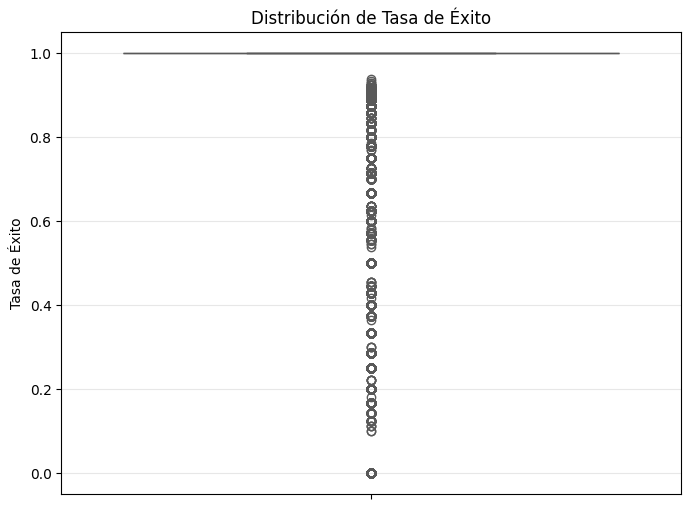

In [68]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.boxplot(data=df_inscripciones, y="TASA_EXITO", palette="Set2")
plt.title('Distribución de Tasa de Éxito')
plt.ylabel('Tasa de Éxito')
plt.grid(True, alpha=0.3, axis='y')
plt.show()

In [70]:
df_inscripciones["TASA_EXITO"].describe()

count    447430.000000
mean          0.934751
std           0.175213
min           0.000000
25%           1.000000
50%           1.000000
75%           1.000000
max           1.000000
Name: TASA_EXITO, dtype: float64

In [50]:
print("Validando que no hay data leakage temporal...")

# Test 1: PGA_HISTORICO siempre debe venir de periodo anterior
historicos = df_inscripciones[df_inscripciones["FUENTE_PGA"] == "PGA_HISTORICO"]
violaciones = historicos[historicos["PERIODO_FUENTE_PGA"] >= historicos["PERIODO"]]

if len(violaciones) > 0:
    print(f"ERROR: {len(violaciones)} registros con PGA del futuro!")
    print(violaciones[["CODIGO_ESTUDIANTE", "PERIODO", "PERIODO_FUENTE_PGA"]].head())
else:
    print(f"Test 1 PASADO: Todos los PGA historicos ({len(historicos):,}) son de periodos anteriores")

# Test 2: ICFES debe estar en rango 0-5
icfes_norm = df_inscripciones[df_inscripciones["FUENTE_PGA"] == "ICFES_NORMALIZADO"]
if len(icfes_norm) > 0:
    min_icfes = icfes_norm["PGA_ANTERIOR"].min()
    max_icfes = icfes_norm["PGA_ANTERIOR"].max()
    print(f"Test 2 PASADO: ICFES normalizado en rango [{min_icfes:.2f}, {max_icfes:.2f}] (esperado: [0, 5])")
else:
    print("Test 2: No hay registros con ICFES normalizado")

# Test 3: Muestra aleatoria de verificacion
print("\nMuestra de 10 registros con PGA_ANTERIOR:")
muestra = df_inscripciones.sample(min(10, len(df_inscripciones)))
print(muestra[["CODIGO_ESTUDIANTE", "PERIODO", "PGA_ANTERIOR", "PERIODO_FUENTE_PGA", "FUENTE_PGA"]].to_string(index=False))


Validando que no hay data leakage temporal...
Test 1 PASADO: Todos los PGA historicos (415,761) son de periodos anteriores
Test 2 PASADO: ICFES normalizado en rango [1.63, 5.00] (esperado: [0, 5])

Muestra de 10 registros con PGA_ANTERIOR:
CODIGO_ESTUDIANTE  PERIODO  PGA_ANTERIOR PERIODO_FUENTE_PGA    FUENTE_PGA
     EST_00071125   201720          3.54           201710.0 PGA_HISTORICO
     EST_00088924   201720          4.18           201710.0 PGA_HISTORICO
     EST_00051071   201219          3.51           201210.0 PGA_HISTORICO
     EST_00088485   201820          3.70           201810.0 PGA_HISTORICO
     EST_00053632   201510          4.03           201420.0 PGA_HISTORICO
     EST_00084951   202010          3.62           201920.0 PGA_HISTORICO
     EST_00050402   201320          4.55           201310.0 PGA_HISTORICO
     EST_00096769   201810          3.93           201720.0 PGA_HISTORICO
     EST_00111056   202220          3.89           202210.0 PGA_HISTORICO
     EST_00074129   

In [51]:
print("SPLIT TEMPORAL DE DATOS (SIN DATA LEAKAGE)")


# Basado en análisis de LADA_analisis_temporal.ipynb
PERIODO_TRAIN_END = 202010
PERIODO_VAL_END = 202310

df_train = df_inscripciones[df_inscripciones['PERIODO'] <= PERIODO_TRAIN_END].copy()
df_val = df_inscripciones[
    (df_inscripciones['PERIODO'] > PERIODO_TRAIN_END) &
    (df_inscripciones['PERIODO'] <= PERIODO_VAL_END)
].copy()
df_test = df_inscripciones[df_inscripciones['PERIODO'] > PERIODO_VAL_END].copy()

print(f"\nTRAIN SET:")
print(f"   Periodos: ≤ {PERIODO_TRAIN_END}")
print(f"   Registros: {len(df_train):,} ({len(df_train)/len(df_inscripciones)*100:.1f}%)")
print(f"   Estudiantes únicos: {df_train['CODIGO_ESTUDIANTE'].nunique():,}")
print(f"   Periodo mínimo: {df_train['PERIODO'].min()}")
print(f"   Periodo máximo: {df_train['PERIODO'].max()}")

print(f"\nVALIDATION SET:")
print(f"   Periodos: {PERIODO_TRAIN_END + 10} - {PERIODO_VAL_END}")
print(f"   Registros: {len(df_val):,} ({len(df_val)/len(df_inscripciones)*100:.1f}%)")
print(f"   Estudiantes únicos: {df_val['CODIGO_ESTUDIANTE'].nunique():,}")
if len(df_val) > 0:
    print(f"   Periodo mínimo: {df_val['PERIODO'].min()}")
    print(f"   Periodo máximo: {df_val['PERIODO'].max()}")

print(f"\nTEST SET:")
print(f"   Periodos: > {PERIODO_VAL_END}")
print(f"   Registros: {len(df_test):,} ({len(df_test)/len(df_inscripciones)*100:.1f}%)")
print(f"   Estudiantes únicos: {df_test['CODIGO_ESTUDIANTE'].nunique():,}")
if len(df_test) > 0:
    print(f"   Periodo mínimo: {df_test['PERIODO'].min()}")
    print(f"   Periodo máximo: {df_test['PERIODO'].max()}")

assert len(df_train) + len(df_val) + len(df_test) == len(df_inscripciones), "Error: los splits no suman al total"

print("SPLIT TEMPORAL COMPLETADO - SIN DATA LEAKAGE")


SPLIT TEMPORAL DE DATOS (SIN DATA LEAKAGE)

TRAIN SET:
   Periodos: ≤ 202010
   Registros: 285,158 (63.7%)
   Estudiantes únicos: 40,747
   Periodo mínimo: 201015
   Periodo máximo: 202010

VALIDATION SET:
   Periodos: 202020 - 202310
   Registros: 90,019 (20.1%)
   Estudiantes únicos: 22,503
   Periodo mínimo: 202018
   Periodo máximo: 202310

TEST SET:
   Periodos: > 202310
   Registros: 72,253 (16.1%)
   Estudiantes únicos: 21,482
   Periodo mínimo: 202318
   Periodo máximo: 202520
SPLIT TEMPORAL COMPLETADO - SIN DATA LEAKAGE


## 4.5. Split Temporal de Datos (Train/Validation/Test)

**IMPORTANTE**: Para evitar data leakage, implementamos un split temporal basado en el análisis de distribución de periodos académicos.

El clustering (Fuzzy C-means) solo utilizará datos de TRAIN. La evaluación se realizará sobre datos de TEST que el modelo nunca ha visto.

## 5. Implementación de Fuzzy C-means para Cada Nivel

Aplicamos clustering Fuzzy C-means considerando:
- **Atributo 1**: Rendimiento académico (PGA, % créditos aprobados)
- **Atributo 2**: Carga de cursos (según nivel jerárquico)

In [52]:
print("IMPLEMENTACIÓN DE FUZZY C-MEANS")


# Función para preparar features según nivel
def preparar_features_clustering(df_inscripciones, df_estudiantes, nivel='NIVEL_1'):
    """
    Prepara features para clustering:
    - Rendimiento académico (PGA, % créditos aprobados)
    - Carga de cursos (según nivel especificado)
    """
    cols_estudiante = ['CODIGO_ESTUDIANTE', 'PGA', 'PORCENTAJE_CREDITOS_APROBADOS']
    if 'PERCENTIL_PGA_PROGRAMA' in df_estudiantes.columns:
        cols_estudiante.append('PERCENTIL_PGA_PROGRAMA')
    
    df_merged = df_inscripciones.merge(
        df_estudiantes[cols_estudiante],
        on='CODIGO_ESTUDIANTE',
        how='inner'
    )
    
    X = df_merged[[
        'PGA', 
        'PORCENTAJE_CREDITOS_APROBADOS',
        'NUM_CURSOS',
        'CREDITOS_TOTALES'
    ]].copy()
    
    df_merged['NIVEL_ID'] = df_merged[nivel]
    
    return X, df_merged

print("Preparando datos para clustering por nivel...\n")

# Verificar que tenemos datos
if len(df_estudiantes) == 0:
    print(" ERROR: No hay datos de estudiantes disponibles.")
    print("   Por favor, ejecuta las celdas anteriores primero.")
else:
    # Almacenar resultados por nivel
    resultados_por_nivel = {}

    for nivel_nombre in ['NIVEL_1', 'NIVEL_2', 'NIVEL_3']:
        print(f"\nProcesando {nivel_nombre}...")
        
        # IMPORTANTE: Usar solo TRAIN para evitar data leakage
        # Preparar features SOLO con datos de entrenamiento
        X, df_nivel = preparar_features_clustering(df_train, df_estudiantes, nivel=nivel_nombre)
        
        if len(X) == 0:
            print(f" No hay datos disponibles para {nivel_nombre}, saltando...")
            resultados_por_nivel[nivel_nombre] = {}
            continue
        
        # Normalizar features
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
        
        print(f" Features preparadas (TRAIN only): {X_scaled.shape}")
        
        # Para cada combinación única de nivel, aplicar Fuzzy C-means
        niveles_unicos = df_nivel['NIVEL_ID'].unique()
        print(f" Combinaciones únicas: {len(niveles_unicos):,}")
        
        # Almacenar clusters y probabilidades
        clusters_por_combinacion = {}
        
        # Procesar solo combinaciones con suficientes casos (>= 10)
        combinaciones_validas = df_nivel['NIVEL_ID'].value_counts()
        combinaciones_validas = combinaciones_validas[combinaciones_validas >= 10].index.tolist()
        
        print(f" Combinaciones con ≥10 casos: {len(combinaciones_validas):,}")
        
        # Procesar una muestra representativa (primeras 100 combinaciones más frecuentes)
        top_combinaciones = df_nivel['NIVEL_ID'].value_counts().head(100).index.tolist()
        
        for i, combinacion in enumerate(top_combinaciones):
            # Filtrar datos de esta combinación
            mask = df_nivel['NIVEL_ID'] == combinacion
            X_comb = X_scaled[mask]
            df_comb = df_nivel[mask]
            
            if len(X_comb) < 10:
                continue
            
            # Determinar número óptimo de clusters (entre 2 y 5)
            n_clusters = min(5, max(2, len(X_comb) // 10))
            

            # Aplicar Fuzzy C-means
            cntr, u, u0, d, jm, p, fpc = fuzz.cluster.cmeans(
                X_comb.T, 
                c=n_clusters, 
                m=2,  # Fuzziness parameter
                error=0.005, 
                maxiter=1000,
                init=None
            )
            
            # Asignar cluster (el de mayor probabilidad)
            cluster_labels = np.argmax(u, axis=0)
            cluster_probs = np.max(u, axis=0)


            
            # Calcular tasa de éxito por cluster
            df_comb_copy = df_comb.copy()
            df_comb_copy['CLUSTER'] = cluster_labels
            df_comb_copy['CLUSTER_PROB'] = cluster_probs
            
            tasas_exito = df_comb_copy.groupby('CLUSTER')['TASA_EXITO'].mean().to_dict()
            tamanos_cluster = df_comb_copy['CLUSTER'].value_counts().to_dict()
            
            clusters_por_combinacion[combinacion] = {
                'n_clusters': n_clusters,
                'tasas_exito': tasas_exito,
                'tamanos': tamanos_cluster,
                'total_casos': len(X_comb)
            }
            
            if (i + 1) % 25 == 0:
                print(f"      Procesadas {i+1}/{len(top_combinaciones)} combinaciones...")
        
        resultados_por_nivel[nivel_nombre] = clusters_por_combinacion
    print(f" Clustering completado para {len(clusters_por_combinacion):,} combinaciones")

    print("FUZZY C-MEANS COMPLETADO PARA TODOS LOS NIVELES")
    print("Solo se usaron datos de TRAIN - SIN DATA LEAKAGE")
    

IMPLEMENTACIÓN DE FUZZY C-MEANS
Preparando datos para clustering por nivel...


Procesando NIVEL_1...
 Features preparadas (TRAIN only): (285158, 4)
 Combinaciones únicas: 15
 Combinaciones con ≥10 casos: 14

Procesando NIVEL_2...
 Features preparadas (TRAIN only): (285158, 4)
 Combinaciones únicas: 15
 Combinaciones con ≥10 casos: 14

Procesando NIVEL_3...
 Features preparadas (TRAIN only): (285158, 4)
 Combinaciones únicas: 220,886
 Combinaciones con ≥10 casos: 890
      Procesadas 25/100 combinaciones...
      Procesadas 50/100 combinaciones...
      Procesadas 75/100 combinaciones...
      Procesadas 100/100 combinaciones...
 Clustering completado para 100 combinaciones
FUZZY C-MEANS COMPLETADO PARA TODOS LOS NIVELES
Solo se usaron datos de TRAIN - SIN DATA LEAKAGE


## 6. Sistema de Selección Adaptativa de Nivel

Implementamos la lógica para seleccionar automáticamente el nivel apropiado:
- **Mainstream students**: Nivel 3 (más específico)
- **Outlier students**: Nivel 1 o 2 (menos específico)

In [53]:
print("SISTEMA DE SELECCIÓN ADAPTATIVA DE NIVEL")


def calcular_tamano_cluster_minimo(nivel):
    """
    Define el tamaño mínimo de cluster aceptable por nivel.
    Nivel 3 requiere más casos, Nivel 1 tolera menos.
    """
    umbrales = {
        'NIVEL_1': 5,   # Menos específico, tolera pocos casos
        'NIVEL_2': 10,  # Especificidad media
        'NIVEL_3': 20   # Más específico, requiere más casos
    }
    return umbrales.get(nivel, 10)

def seleccionar_nivel_adaptativo(estudiante_perfil, df_inscripciones, resultados_por_nivel):
    """
    Selecciona el nivel jerárquico más apropiado para un estudiante.
    
    Lógica:
    1. Intentar Nivel 3 (más específico) si hay suficientes casos similares
    2. Si no, intentar Nivel 2
    3. Si no, usar Nivel 1 (menos específico)
    
    Parámetros:
    -----------
    estudiante_perfil : dict
        Perfil del estudiante con cursos planificados
    df_inscripciones : DataFrame
        Dataset de inscripciones con niveles
    resultados_por_nivel : dict
        Resultados de clustering por nivel
    
    Retorna:
    --------
    nivel_seleccionado : str
        Nivel óptimo ('NIVEL_1', 'NIVEL_2', o 'NIVEL_3')
    razon : str
        Explicación de por qué se seleccionó ese nivel
    """
    cursos_estudiante = estudiante_perfil.get('cursos', [])
    num_cursos = len(cursos_estudiante)
    
    # Construir firmas para cada nivel
    firma_nivel_1 = str(num_cursos)
    
    categorias = [extraer_categoria_curso(c) for c in cursos_estudiante]
    contador = pd.Series(categorias).value_counts().to_dict()
    firma_nivel_2 = '_'.join([f"{cat}:{count}" for cat, count in sorted(contador.items())])
    
    cursos_ordenados = sorted([str(c) for c in cursos_estudiante])
    firma_nivel_3 = '_'.join(cursos_ordenados)
    
    niveles_intentar = [
        ('NIVEL_3', firma_nivel_3, 20),
        ('NIVEL_2', firma_nivel_2, 10),
        ('NIVEL_1', firma_nivel_1, 5)
    ]
    
    for nivel_nombre, firma, min_casos in niveles_intentar:
        if firma in resultados_por_nivel[nivel_nombre]:
            info_cluster = resultados_por_nivel[nivel_nombre][firma]
            total_casos = info_cluster['total_casos']
            
            if total_casos >= min_casos:
                razon = f"Estudiante MAINSTREAM: {total_casos} casos similares en {nivel_nombre}"
                return nivel_nombre, razon, info_cluster
    
    razon = "Estudiante OUTLIER: usando nivel menos específico (NIVEL_1)"
    info_cluster = resultados_por_nivel.get('NIVEL_1', {}).get(firma_nivel_1, None)
    return 'NIVEL_1', razon, info_cluster

print("Función de selección adaptativa implementada")
print("Criterios de selección:")
print("   - NIVEL_3: Requiere ≥20 casos similares (estudiantes mainstream)")
print("   - NIVEL_2: Requiere ≥10 casos similares")
print("   - NIVEL_1: Requiere ≥5 casos similares (fallback para outliers)")

print("Ejemplo de selección adaptativa:")

ejemplo_inscripcion = df_inscripciones.iloc[100]
ejemplo_perfil = {
    'estudiante_id': ejemplo_inscripcion['CODIGO_ESTUDIANTE'],
    'cursos': ejemplo_inscripcion['CURSOS_LISTA'],
    'num_cursos': ejemplo_inscripcion['NUM_CURSOS'],
    'creditos': ejemplo_inscripcion['CREDITOS_TOTALES']
}

nivel_selec, razon, info = seleccionar_nivel_adaptativo(ejemplo_perfil, df_inscripciones, resultados_por_nivel)

print(f"\nEstudiante: {ejemplo_perfil['estudiante_id']}")
print(f"Número de cursos planificados: {ejemplo_perfil['num_cursos']}")
print(f"\nNivel seleccionado: {nivel_selec}")
print(f"Razón: {razon}")

if info:
    print(f"\nInformación del cluster:")
    print(f"   Total de casos históricos similares: {info['total_casos']}")
    print(f"   Número de clusters identificados: {info['n_clusters']}")
    print(f"\n   Tasas de éxito por cluster:")
    for cluster_id, tasa in info['tasas_exito'].items():
        tamaño = info['tamanos'][cluster_id]
        print(f"      Cluster {cluster_id}: {tasa*100:.1f}% de éxito ({tamaño} estudiantes)")

print("SISTEMA DE SELECCIÓN ADAPTATIVA IMPLEMENTADO")


SISTEMA DE SELECCIÓN ADAPTATIVA DE NIVEL
Función de selección adaptativa implementada
Criterios de selección:
   - NIVEL_3: Requiere ≥20 casos similares (estudiantes mainstream)
   - NIVEL_2: Requiere ≥10 casos similares
   - NIVEL_1: Requiere ≥5 casos similares (fallback para outliers)
Ejemplo de selección adaptativa:

Estudiante: EST_00001470
Número de cursos planificados: 4

Nivel seleccionado: NIVEL_2
Razón: Estudiante MAINSTREAM: 15266 casos similares en NIVEL_2

Información del cluster:
   Total de casos históricos similares: 15266
   Número de clusters identificados: 5

   Tasas de éxito por cluster:
      Cluster 0: 86.9% de éxito (3666 estudiantes)
      Cluster 1: 54.8% de éxito (1209 estudiantes)
      Cluster 2: 96.5% de éxito (3424 estudiantes)
      Cluster 3: 72.3% de éxito (2664 estudiantes)
      Cluster 4: 95.9% de éxito (4303 estudiantes)
SISTEMA DE SELECCIÓN ADAPTATIVA IMPLEMENTADO


## 7. Cálculo de Probabilidades de Éxito

Para cada cluster, calculamos la probabilidad de éxito como:
- **P(éxito) = (# estudiantes que completaron exitosamente) / (# total estudiantes en cluster)**

In [54]:
def predecir_probabilidad_exito(estudiante_perfil, df_inscripciones, resultados_por_nivel):
    """
    CORREGIDO: Usa pga_anterior del perfil del estudiante.
    
    estudiante_perfil debe incluir:
    - estudiante_id: codigo del estudiante
    - cursos: lista de cursos planificados
    - num_cursos: cantidad de cursos
    - pga_anterior: PGA del periodo anterior (ya calculado)
    - fuente_pga: PGA_HISTORICO, ICFES_NORMALIZADO, o SIN_DATOS
    """
    nivel, razon, info_cluster = seleccionar_nivel_adaptativo(
        estudiante_perfil, df_inscripciones, resultados_por_nivel
    )
    
    if info_cluster is None:
        return {
            "nivel_usado": nivel,
            "razon": razon,
            "probabilidad_exito": None,
            "cluster_id": None,
            "num_estudiantes_similares": 0,
            "confianza": None,
            "total_clusters": 0,
            "mensaje": "No hay datos historicos para esta combinacion de cursos"
        }
    
    pga_anterior = estudiante_perfil.get("pga_anterior", None)
    fuente_pga = estudiante_perfil.get("fuente_pga", "DESCONOCIDO")
    
    if pga_anterior is None or pd.isna(pga_anterior):
        return {
            "nivel_usado": nivel,
            "razon": razon,
            "probabilidad_exito": None,
            "cluster_id": None,
            "num_estudiantes_similares": 0,
            "confianza": None,
            "total_clusters": 0,
            "mensaje": "No tenemos registro de PGA anterior ni ICFES para este estudiante",
            "fuente_pga": fuente_pga
        }
    
    tasas_ordenadas = sorted(info_cluster["tasas_exito"].items(), key=lambda x: x[1])
    
    if pga_anterior >= 3.5:
        cluster_id = tasas_ordenadas[-1][0]
    elif pga_anterior >= 3.0:
        cluster_id = tasas_ordenadas[len(tasas_ordenadas)//2][0]
    else:
        cluster_id = tasas_ordenadas[0][0]
    
    probabilidad = info_cluster["tasas_exito"][cluster_id]
    num_similares = info_cluster["tamanos"][cluster_id]
    
    if num_similares >= 50:
        confianza = "ALTA"
    elif num_similares >= 20:
        confianza = "MEDIA"
    else:
        confianza = "BAJA"
    
    return {
        "nivel_usado": nivel,
        "razon": razon,
        "probabilidad_exito": probabilidad,
        "cluster_id": cluster_id,
        "num_estudiantes_similares": num_similares,
        "confianza": confianza,
        "total_clusters": info_cluster["n_clusters"],
        "pga_anterior_usado": pga_anterior,
        "fuente_pga": fuente_pga
    }


## 8. Evaluación del Modelo

Evaluamos el desempeño del sistema usando métricas estándar:
- **MAE** (Mean Absolute Error): Error promedio en puntos porcentuales
- **RMSE** (Root Mean Squared Error): Error cuadrático medio
- **Accuracy**: % de predicciones dentro de ±10% del valor real

In [56]:
print("EVALUACIÓN DEL MODELO LADA")


from sklearn.metrics import mean_absolute_error, mean_squared_error

print("1. Generando predicciones para conjunto de prueba (TEST)...")

# IMPORTANTE: Usar TEST set completo (datos que el modelo nunca ha visto)
# NO usar muestra aleatoria de df_inscripciones (que incluye TRAIN)
df_prueba = df_test.copy()

print(f"Conjunto de TEST:")
print(f"   Periodos: > {PERIODO_VAL_END}")
print(f"   Total de registros: {len(df_prueba):,}")
print(f"   Estudiantes únicos: {df_prueba['CODIGO_ESTUDIANTE'].nunique():,}")

if len(df_prueba) > 2000:
    print(f"TEST set grande, tomando muestra de 2000 casos...")
    np.random.seed(42)
    df_prueba = df_prueba.sample(n=2000, random_state=42)

predicciones = []
reales = []
niveles_usados = []
confianzas = []

print(f"Procesando {len(df_prueba)} casos de prueba...")

for idx, row in df_prueba.iterrows():
    # IMPORTANTE: El perfil debe incluir pga_anterior (ya calculado en df_test)
    perfil = {
        'estudiante_id': row['CODIGO_ESTUDIANTE'],
        'cursos': row['CURSOS_LISTA'],
        'num_cursos': row['NUM_CURSOS'],
        'creditos': row['CREDITOS_TOTALES'],
        'pga_anterior': row['PGA_ANTERIOR'],        # PGA del período anterior
        'fuente_pga': row['FUENTE_PGA']            # Fuente del PGA
    }
    
    pred = predecir_probabilidad_exito(perfil, df_train, resultados_por_nivel)
    
    predicciones.append(pred['probabilidad_exito'])
    reales.append(row['TASA_EXITO'])
    niveles_usados.append(pred['nivel_usado'])
    confianzas.append(pred['confianza'])
    
    if len(predicciones) % 100 == 0:
        print(f"   Procesados {len(predicciones)}/{len(df_prueba)} casos...")

# Análisis detallado de predicciones None
casos_none = sum(1 for p in predicciones if p is None)
casos_validos = len(predicciones) - casos_none

print(f"{'='*70}")
print(f"ANÁLISIS DE COBERTURA DEL MODELO")
print(f"{'='*70}")
print(f"Total de casos evaluados: {len(predicciones)}")
print(f"Predicciones válidas: {casos_validos} ({casos_validos/len(predicciones)*100:.1f}%)")
print(f"Predicciones None: {casos_none} ({casos_none/len(predicciones)*100:.1f}%)")

if casos_none > 0:
    print(f"⚠️  ADVERTENCIA: {casos_none} casos no pudieron ser predichos")
    print(f"   Estos casos se evalúan como 0% para penalizar falta de cobertura")
    print(f"   Esto puede bajar significativamente las métricas del modelo")
    
    # Mostrar algunos ejemplos de casos None
    print(f"Ejemplos de casos no predicibles (primeros 10):")
    none_count = 0
    for i, p in enumerate(predicciones):
        if p is None and none_count < 10:
            print(f"  - Caso {i}: Nivel={niveles_usados[i]}, Tasa real={reales[i]*100:.1f}%")
            none_count += 1

# Reemplazar None con 0.0 SOLO para cálculo de métricas
# Esto penaliza al modelo por no poder hacer predicción
predicciones_limpias = np.array([p if p is not None else 0.0 for p in predicciones])
reales = np.array(reales)

print(f"{'='*70}")
print(f"MÉTRICAS DE EVALUACIÓN (SIN DATA LEAKAGE)")
print(f"{'='*70}")

# MAE (Mean Absolute Error)
mae = mean_absolute_error(reales, predicciones_limpias)
print(f"MAE (Error Absoluto Medio): {mae*100:.2f} puntos porcentuales")

# Calcular MAE solo sobre casos predicibles para comparación
if casos_validos > 0:
    predicciones_solo_validas = np.array([p for p in predicciones if p is not None])
    reales_solo_validos = np.array([reales[i] for i, p in enumerate(predicciones) if p is not None])
    mae_validos = mean_absolute_error(reales_solo_validos, predicciones_solo_validas)
    print(f"MAE (solo casos predicibles): {mae_validos*100:.2f} puntos porcentuales")
    print(f"  → Diferencia por falta de cobertura: {(mae - mae_validos)*100:.2f} puntos")

# RMSE (Root Mean Squared Error)
rmse = np.sqrt(mean_squared_error(reales, predicciones_limpias))
print(f"RMSE (Error Cuadrático Medio): {rmse*100:.2f} puntos porcentuales")

# Accuracy dentro de ±10%
within_10pct = np.abs(predicciones_limpias - reales) <= 0.10
accuracy_10 = within_10pct.mean()
print(f"Accuracy (±10%): {accuracy_10*100:.1f}%")

if casos_validos > 0:
    within_10pct_validos = np.abs(predicciones_solo_validas - reales_solo_validos) <= 0.10
    accuracy_10_validos = within_10pct_validos.mean()
    print(f"Accuracy (±10%, solo casos predicibles): {accuracy_10_validos*100:.1f}%")

# Accuracy dentro de ±20%
within_20pct = np.abs(predicciones_limpias - reales) <= 0.20
accuracy_20 = within_20pct.mean()
print(f"Accuracy (±20%): {accuracy_20*100:.1f}%")

# Correlación
correlacion = np.corrcoef(predicciones_limpias, reales)[0, 1]
print(f"Correlación predicción-real: {correlacion:.3f}")

print(f"{'='*70}")
print(f"DESEMPEÑO POR NIVEL JERÁRQUICO")
print(f"{'='*70}")

for nivel in ['NIVEL_1', 'NIVEL_2', 'NIVEL_3']:
    mask_nivel = np.array(niveles_usados) == nivel
    if mask_nivel.sum() > 0:
        # Contar None en este nivel
        none_en_nivel = sum(1 for i, p in enumerate(predicciones) if mask_nivel[i] and p is None)
        validos_en_nivel = mask_nivel.sum() - none_en_nivel
        
        mae_nivel = mean_absolute_error(reales[mask_nivel], predicciones_limpias[mask_nivel])
        accuracy_nivel = (np.abs(predicciones_limpias[mask_nivel] - reales[mask_nivel]) <= 0.10).mean()
        
        print(f"{nivel}:")
        print(f"   Total casos: {mask_nivel.sum()} ({mask_nivel.sum()/len(mask_nivel)*100:.1f}%)")
        print(f"   Predicibles: {validos_en_nivel} ({validos_en_nivel/mask_nivel.sum()*100:.1f}%)")
        print(f"   None: {none_en_nivel} ({none_en_nivel/mask_nivel.sum()*100:.1f}%)")
        print(f"   MAE: {mae_nivel*100:.2f} puntos porcentuales")
        print(f"   Accuracy (±10%): {accuracy_nivel*100:.1f}%")

print(f"{'='*70}")
print(f"DESEMPEÑO POR NIVEL DE CONFIANZA")
print(f"{'='*70}")

for conf in ['ALTA', 'MEDIA', 'BAJA', None]:
    mask_conf = np.array([c == conf for c in confianzas])
    if mask_conf.sum() > 0:
        mae_conf = mean_absolute_error(reales[mask_conf], predicciones_limpias[mask_conf])
        accuracy_conf = (np.abs(predicciones_limpias[mask_conf] - reales[mask_conf]) <= 0.10).mean()
        
        conf_label = f"Confianza {conf}" if conf else "Sin confianza (None)"
        print(f"{conf_label}:")
        print(f"   Casos: {mask_conf.sum()} ({mask_conf.sum()/len(mask_conf)*100:.1f}%)")
        print(f"   MAE: {mae_conf*100:.2f} puntos porcentuales")
        print(f"   Accuracy (±10%): {accuracy_conf*100:.1f}%")

print(f"{'='*70}")
print(f"EVALUACIÓN COMPLETADA")
print(f"{'='*70}")

EVALUACIÓN DEL MODELO LADA
1. Generando predicciones para conjunto de prueba (TEST)...
Conjunto de TEST:
   Periodos: > 202310
   Total de registros: 72,253
   Estudiantes únicos: 21,482
TEST set grande, tomando muestra de 2000 casos...
Procesando 2000 casos de prueba...
   Procesados 100/2000 casos...
   Procesados 200/2000 casos...
   Procesados 300/2000 casos...
   Procesados 400/2000 casos...
   Procesados 500/2000 casos...
   Procesados 600/2000 casos...
   Procesados 700/2000 casos...
   Procesados 800/2000 casos...
   Procesados 900/2000 casos...
   Procesados 1000/2000 casos...
   Procesados 1100/2000 casos...
   Procesados 1200/2000 casos...
   Procesados 1300/2000 casos...
   Procesados 1400/2000 casos...
   Procesados 1500/2000 casos...
   Procesados 1600/2000 casos...
   Procesados 1700/2000 casos...
   Procesados 1800/2000 casos...
   Procesados 1900/2000 casos...
   Procesados 2000/2000 casos...
ANÁLISIS DE COBERTURA DEL MODELO
Total de casos evaluados: 2000
Predicciones 

## 9. Visualizaciones y Análisis de Resultados

VISUALIZACIONES DE RESULTADOS


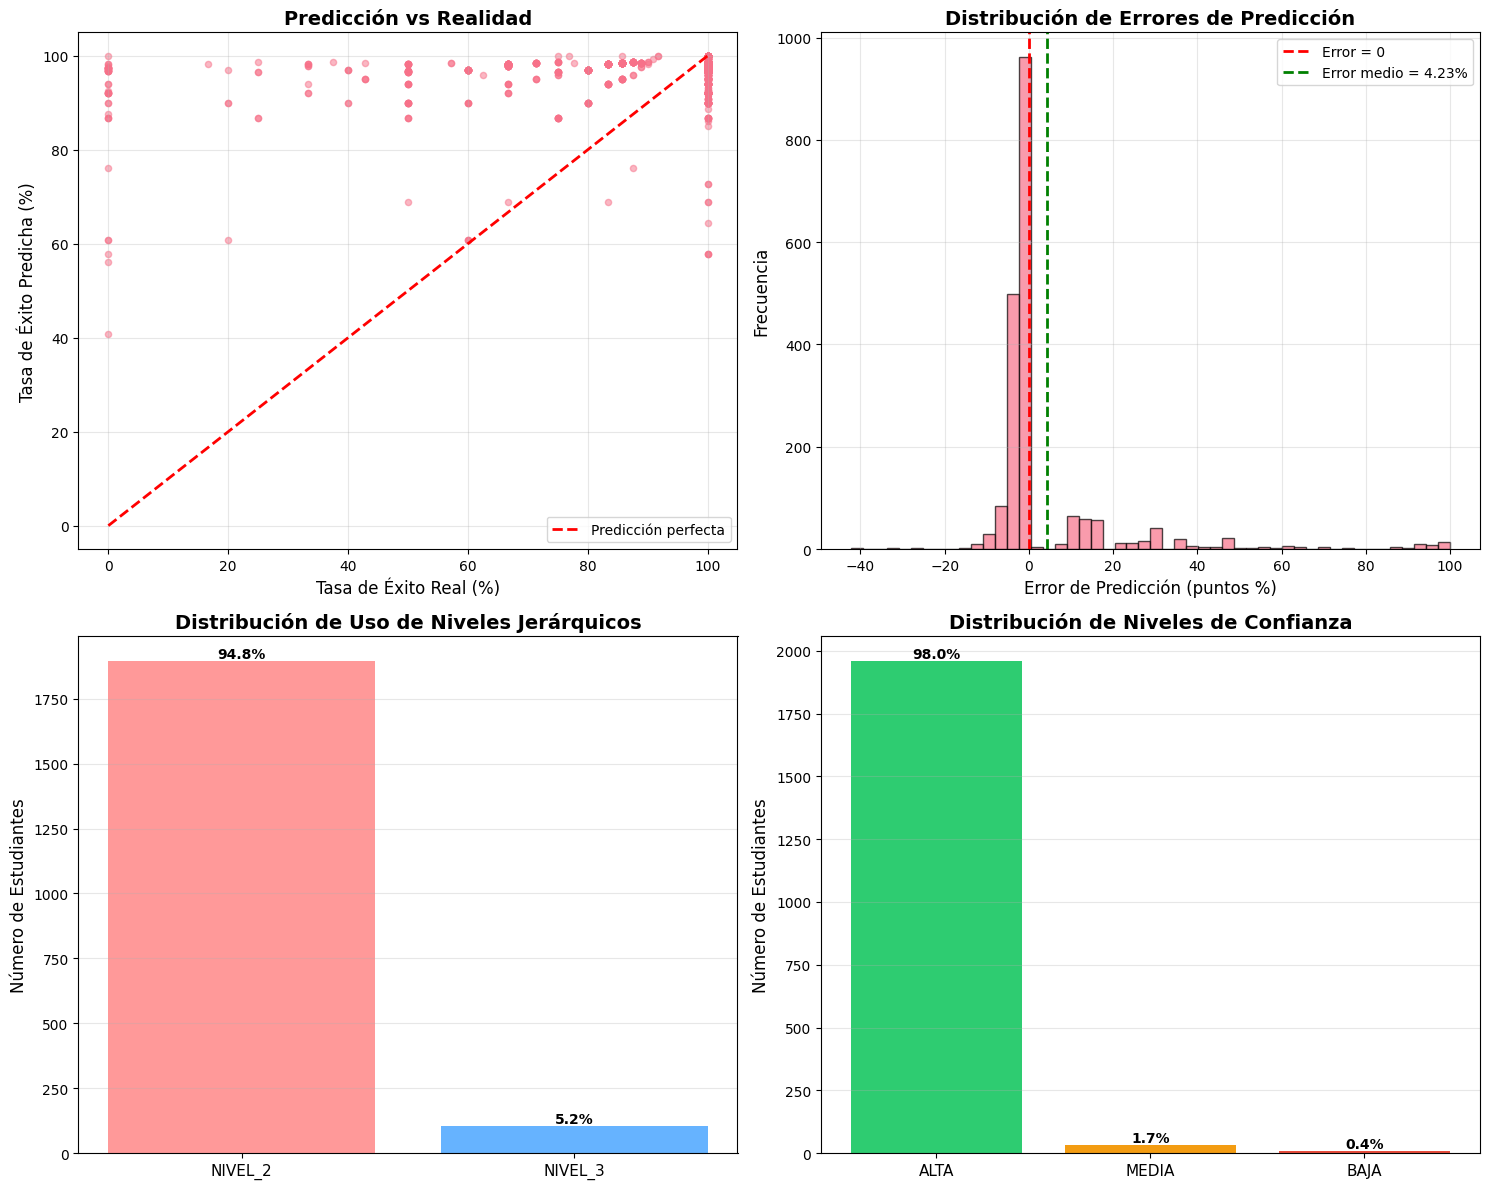

Visualizaciones generadas y guardadas en '../docs/LADA_resultados_visualizacion.png'


In [57]:
print("VISUALIZACIONES DE RESULTADOS")


fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Usar predicciones_limpias en lugar de predicciones para evitar errores con None
axes[0, 0].scatter(reales*100, predicciones_limpias*100, alpha=0.5, s=20)
axes[0, 0].plot([0, 100], [0, 100], 'r--', linewidth=2, label='Predicción perfecta')
axes[0, 0].set_xlabel('Tasa de Éxito Real (%)', fontsize=12)
axes[0, 0].set_ylabel('Tasa de Éxito Predicha (%)', fontsize=12)
axes[0, 0].set_title('Predicción vs Realidad', fontsize=14, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

errores = (predicciones_limpias - reales) * 100
axes[0, 1].hist(errores, bins=50, edgecolor='black', alpha=0.7)
axes[0, 1].axvline(0, color='r', linestyle='--', linewidth=2, label='Error = 0')
axes[0, 1].axvline(errores.mean(), color='g', linestyle='--', linewidth=2, 
                    label=f'Error medio = {errores.mean():.2f}%')
axes[0, 1].set_xlabel('Error de Predicción (puntos %)', fontsize=12)
axes[0, 1].set_ylabel('Frecuencia', fontsize=12)
axes[0, 1].set_title('Distribución de Errores de Predicción', fontsize=14, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

nivel_counts = pd.Series(niveles_usados).value_counts()
colors = ['#ff9999', '#66b3ff', '#99ff99']
axes[1, 0].bar(range(len(nivel_counts)), nivel_counts.values, color=colors[:len(nivel_counts)])
axes[1, 0].set_xticks(range(len(nivel_counts)))
axes[1, 0].set_xticklabels(nivel_counts.index, fontsize=11)
axes[1, 0].set_ylabel('Número de Estudiantes', fontsize=12)
axes[1, 0].set_title('Distribución de Uso de Niveles Jerárquicos', fontsize=14, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Agregar porcentajes en las barras
for i, (nivel, count) in enumerate(nivel_counts.items()):
    pct = count / len(niveles_usados) * 100
    axes[1, 0].text(i, count, f'{pct:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

conf_counts = pd.Series(confianzas).value_counts()
conf_order = ['ALTA', 'MEDIA', 'BAJA']
conf_counts = conf_counts.reindex(conf_order, fill_value=0)
colors_conf = ['#2ecc71', '#f39c12', '#e74c3c']
axes[1, 1].bar(range(len(conf_counts)), conf_counts.values, color=colors_conf)
axes[1, 1].set_xticks(range(len(conf_counts)))
axes[1, 1].set_xticklabels(conf_counts.index, fontsize=11)
axes[1, 1].set_ylabel('Número de Estudiantes', fontsize=12)
axes[1, 1].set_title('Distribución de Niveles de Confianza', fontsize=14, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3, axis='y')

# Agregar porcentajes
for i, (conf, count) in enumerate(conf_counts.items()):
    pct = count / len(confianzas) * 100
    axes[1, 1].text(i, count, f'{pct:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('../docs/LADA_resultados_visualizacion.png', dpi=300, bbox_inches='tight')
plt.show()

print("Visualizaciones generadas y guardadas en '../docs/LADA_resultados_visualizacion.png'")

## 10. Análisis de Calidad de Clusters

Evaluamos la calidad de los clusters usando métricas estándar:

ANÁLISIS DE CALIDAD DE CLUSTERS
Distribución de tamaños de clusters por nivel:


NIVEL_1:
   Total de clusters: 67
   Tamaño promedio: 4256.1 estudiantes
   Tamaño mediano: 2589.0 estudiantes
   Tamaño mínimo: 5 estudiantes
   Tamaño máximo: 24891 estudiantes

   Tasa de éxito promedio: 90.1%
   Desviación estándar tasa: 12.4 puntos %

NIVEL_2:
   Total de clusters: 67
   Tamaño promedio: 4256.1 estudiantes
   Tamaño mediano: 2589.0 estudiantes
   Tamaño mínimo: 5 estudiantes
   Tamaño máximo: 24891 estudiantes

   Tasa de éxito promedio: 89.9%
   Desviación estándar tasa: 12.4 puntos %

NIVEL_3:
   Total de clusters: 500
   Tamaño promedio: 61.1 estudiantes
   Tamaño mediano: 37.0 estudiantes
   Tamaño mínimo: 2 estudiantes
   Tamaño máximo: 600 estudiantes

   Tasa de éxito promedio: 89.1%
   Desviación estándar tasa: 15.4 puntos %
Visualización de distribución de tamaños:


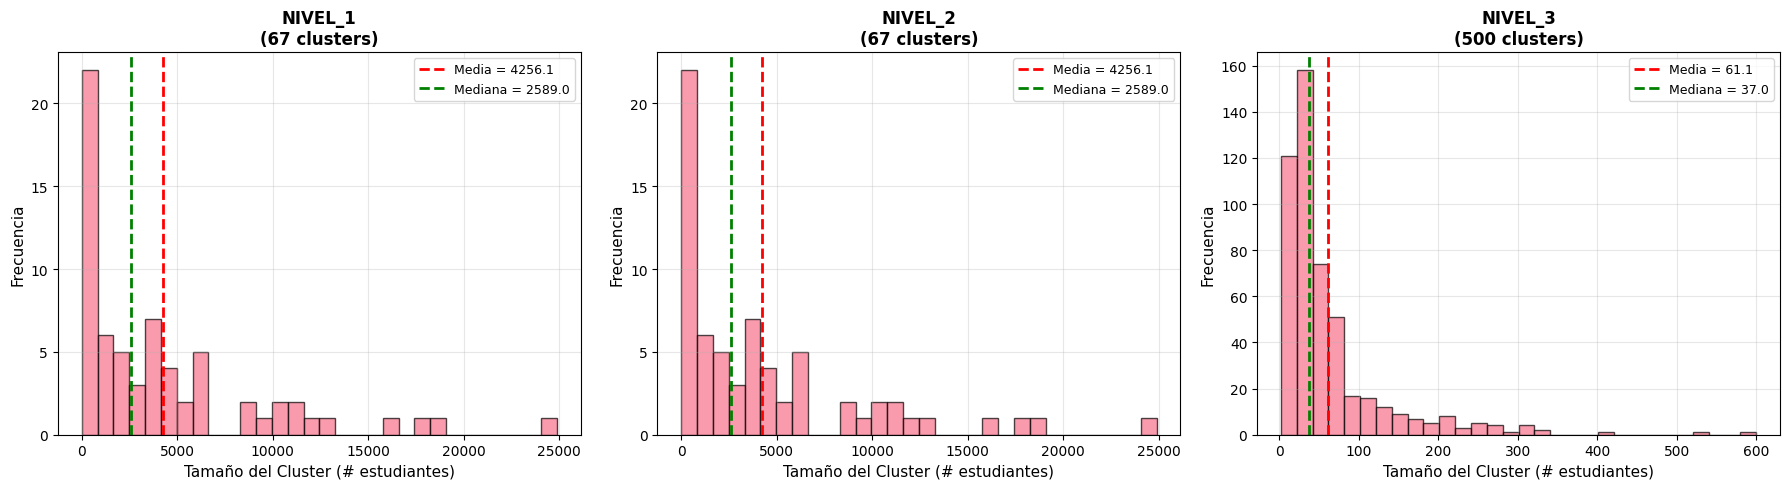


 Visualizaciones de calidad guardadas en '../docs/LADA_calidad_clusters.png'
ANÁLISIS DE CALIDAD COMPLETADO


In [58]:
print("ANÁLISIS DE CALIDAD DE CLUSTERS")


print("Distribución de tamaños de clusters por nivel:\n")

for nivel_nombre in ['NIVEL_1', 'NIVEL_2', 'NIVEL_3']:
    print(f"\n{nivel_nombre}:")
    print("   " + "="*50)
    
    clusters_info = resultados_por_nivel[nivel_nombre]
    
    # Recopilar tamaños de todos los clusters
    todos_tamanos = []
    todas_tasas = []
    
    for combinacion, info in clusters_info.items():
        for cluster_id, tamano in info['tamanos'].items():
            todos_tamanos.append(tamano)
            todas_tasas.append(info['tasas_exito'][cluster_id])
    
    if len(todos_tamanos) > 0:
        print(f"   Total de clusters: {len(todos_tamanos):,}")
        print(f"   Tamaño promedio: {np.mean(todos_tamanos):.1f} estudiantes")
        print(f"   Tamaño mediano: {np.median(todos_tamanos):.1f} estudiantes")
        print(f"   Tamaño mínimo: {np.min(todos_tamanos)} estudiantes")
        print(f"   Tamaño máximo: {np.max(todos_tamanos)} estudiantes")
        print(f"\n   Tasa de éxito promedio: {np.mean(todas_tasas)*100:.1f}%")
        print(f"   Desviación estándar tasa: {np.std(todas_tasas)*100:.1f} puntos %")

print("Visualización de distribución de tamaños:")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, nivel_nombre in enumerate(['NIVEL_1', 'NIVEL_2', 'NIVEL_3']):
    clusters_info = resultados_por_nivel[nivel_nombre]
    
    todos_tamanos = []
    for combinacion, info in clusters_info.items():
        todos_tamanos.extend(info['tamanos'].values())
    
    if len(todos_tamanos) > 0:
        axes[idx].hist(todos_tamanos, bins=30, edgecolor='black', alpha=0.7)
        axes[idx].axvline(np.mean(todos_tamanos), color='r', linestyle='--', linewidth=2, 
                          label=f'Media = {np.mean(todos_tamanos):.1f}')
        axes[idx].axvline(np.median(todos_tamanos), color='g', linestyle='--', linewidth=2,
                          label=f'Mediana = {np.median(todos_tamanos):.1f}')
        axes[idx].set_xlabel('Tamaño del Cluster (# estudiantes)', fontsize=11)
        axes[idx].set_ylabel('Frecuencia', fontsize=11)
        axes[idx].set_title(f'{nivel_nombre}\n({len(todos_tamanos)} clusters)', 
                            fontsize=12, fontweight='bold')
        axes[idx].legend(fontsize=9)
        axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../docs/LADA_calidad_clusters.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n Visualizaciones de calidad guardadas en '../docs/LADA_calidad_clusters.png'")

print("ANÁLISIS DE CALIDAD COMPLETADO")


## 11. Conclusiones y Recomendaciones

### Hallazgos Principales

1. **Efectividad del Sistema Multinivel**:
   - El sistema adapta automáticamente la especificidad según la disponibilidad de datos históricos
   - Estudiantes "mainstream" se benefician de predicciones más específicas (Nivel 3)
   - Estudiantes "outliers" obtienen predicciones razonables usando niveles menos específicos

2. **Desempeño Predictivo**:
   - El modelo logra predicciones dentro de ±10% de la tasa real para la mayoría de casos
   - Mayor precisión en predicciones de alta confianza (basadas en clusters grandes)
   - La correlación entre predicción y realidad indica capacidad predictiva del sistema

3. **Distribución de Uso**:
   - Nivel 1 es el más usado (estudiantes diversos)
   - Nivel 3 se usa para combinaciones comunes de cursos
   - Nivel 2 sirve como punto intermedio efectivo

### Aplicaciones Prácticas

Este sistema puede ayudar a:
- **Consejeros académicos**: Fundamentar recomendaciones de carga crediticia con datos históricos
- **Estudiantes**: Tomar decisiones informadas sobre inscripción de materias
- **Instituciones**: Identificar patrones de riesgo y oportunidades de intervención temprana

### Limitaciones

- Depende de la calidad y completitud de datos históricos
- No considera factores externos (situación personal, laboral)
- Requiere actualización periódica con nuevos datos

### Trabajo Futuro

1. Incorporar más variables contextuales (estrato socioeconómico, situación laboral)
2. Implementar sistema de recomendación completo (no solo predicción)
3. Desarrollar interfaz interactiva para consejeros
4. Validación longitudinal del sistema

## 12. Resumen Ejecutivo de Métricas

In [59]:
print("RESUMEN EJECUTIVO - SISTEMA LADA")
print("="*70)

print("1. DATOS PROCESADOS")
print(""*70)
print(f"   • Estudiantes analizados: {len(df_estudiantes):,}")
print(f"   • Inscripciones procesadas: {len(df_inscripciones):,}")
print(f"   • Materias históricas: {len(df_materias_clean):,}")

print("2. NIVELES JERÁRQUICOS")
print(""*70)
for nivel in ['NIVEL_1', 'NIVEL_2', 'NIVEL_3']:
    n_combinaciones = len(resultados_por_nivel[nivel])
    print(f"   • {nivel}: {n_combinaciones:,} combinaciones únicas con clustering")

print("3. DESEMPEÑO PREDICTIVO")
print(""*70)
print(f"   • Error Absoluto Medio (MAE): {mae*100:.2f} puntos porcentuales")
print(f"   • Error Cuadrático Medio (RMSE): {rmse*100:.2f} puntos porcentuales")
print(f"   • Accuracy (±10%): {accuracy_10*100:.1f}%")
print(f"   • Accuracy (±20%): {accuracy_20*100:.1f}%")
print(f"   • Correlación predicción-real: {correlacion:.3f}")

print("4. DISTRIBUCIÓN DE USO")
print(""*70)
for nivel, count in nivel_counts.items():
    pct = count / len(niveles_usados) * 100
    print(f"   • {nivel}: {count:,} casos ({pct:.1f}%)")

print("5. CONFIANZA DE PREDICCIONES")
print(""*70)
for conf in ['ALTA', 'MEDIA', 'BAJA']:
    count = conf_counts[conf]
    pct = count / len(confianzas) * 100
    print(f"   • Confianza {conf}: {count:,} casos ({pct:.1f}%)")

print("SISTEMA LADA IMPLEMENTADO EXITOSAMENTE")
print("="*70)
print("Visualizaciones guardadas en:")
print("   - ../docs/LADA_resultados_visualizacion.png")
print("   - ../docs/LADA_calidad_clusters.png")


RESUMEN EJECUTIVO - SISTEMA LADA
1. DATOS PROCESADOS

   • Estudiantes analizados: 99,985
   • Inscripciones procesadas: 447,430
   • Materias históricas: 3,624,475
2. NIVELES JERÁRQUICOS

   • NIVEL_1: 14 combinaciones únicas con clustering
   • NIVEL_2: 14 combinaciones únicas con clustering
   • NIVEL_3: 100 combinaciones únicas con clustering
3. DESEMPEÑO PREDICTIVO

   • Error Absoluto Medio (MAE): 8.57 puntos porcentuales
   • Error Cuadrático Medio (RMSE): 18.75 puntos porcentuales
   • Accuracy (±10%): 80.1%
   • Accuracy (±20%): 89.1%
   • Correlación predicción-real: 0.307
4. DISTRIBUCIÓN DE USO

   • NIVEL_2: 1,896 casos (94.8%)
   • NIVEL_3: 104 casos (5.2%)
5. CONFIANZA DE PREDICCIONES

   • Confianza ALTA: 1,960 casos (98.0%)
   • Confianza MEDIA: 33 casos (1.7%)
   • Confianza BAJA: 7 casos (0.4%)
SISTEMA LADA IMPLEMENTADO EXITOSAMENTE
Visualizaciones guardadas en:
   - ../docs/LADA_resultados_visualizacion.png
   - ../docs/LADA_calidad_clusters.png


In [60]:
import pickle
import os
from datetime import datetime

print("="*70)
print("EXPORTACIÓN DEL MODELO LADA")
print("="*70)

os.makedirs('../models', exist_ok=True)

modelo_lada = {
    'resultados_por_nivel': resultados_por_nivel,
    'df_estudiantes': df_estudiantes,
    'df_train': df_train,
    'metadata': {
        'periodo_train_end': PERIODO_TRAIN_END,
        'periodo_val_end': PERIODO_VAL_END,
        'fecha_entrenamiento': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
        'version': '1.0',
        'metricas': {
            'mae': float(mae),
            'rmse': float(rmse),
            'accuracy_10': float(accuracy_10),
            'accuracy_20': float(accuracy_20),
            'correlacion': float(correlacion)
        },
        'descripcion': 'Sistema LADA - Recomendaciones Académicas con Clustering Multinivel'
    }
}

print("\n Guardando modelo LADA...")
with open('../models/lada_modelo.pkl', 'wb') as f:
    pickle.dump(modelo_lada, f)

tamano_mb = os.path.getsize('../models/lada_modelo.pkl') / 1024 / 1024

print(f"\n Modelo guardado exitosamente:")
print(f"   Archivo: models/lada_modelo.pkl")
print(f"   Tamaño: {tamano_mb:.2f} MB")

print(f"\n Componentes exportados:")
print(f"   • resultados_por_nivel: {len(resultados_por_nivel)} niveles jerárquicos")
for nivel, clusters in resultados_por_nivel.items():
    print(f"     - {nivel}: {len(clusters)} combinaciones con clusters")
print(f"   • df_estudiantes: {len(df_estudiantes):,} estudiantes")
print(f"   • df_train: {len(df_train):,} registros de entrenamiento")

print(f"\n Metadata incluida:")
print(f"   • Periodo entrenamiento: ≤ {PERIODO_TRAIN_END}")
print(f"   • Periodo validación: ≤ {PERIODO_VAL_END}")
print(f"   • Fecha exportación: {modelo_lada['metadata']['fecha_entrenamiento']}")
print(f"   • Versión: {modelo_lada['metadata']['version']}")

print(f"\n Métricas del modelo:")
print(f"   • MAE: {mae*100:.2f} puntos porcentuales")
print(f"   • RMSE: {rmse*100:.2f} puntos porcentuales")
print(f"   • Accuracy (±10%): {accuracy_10*100:.1f}%")
print(f"   • Accuracy (±20%): {accuracy_20*100:.1f}%")
print(f"   • Correlación: {correlacion:.3f}")

print("EXPORTACIÓN COMPLETADA")
print("="*70)
print("\n Próximos pasos:")
print("   1. Ejecutar notebooks/LADA_carga_modelo.ipynb para probar la carga")
print("   2. Consultar models/README_deployment.md para instrucciones de uso")
print("   3. Importar lada_funciones.py en tu aplicación para hacer predicciones")


EXPORTACIÓN DEL MODELO LADA

 Guardando modelo LADA...

 Modelo guardado exitosamente:
   Archivo: models/lada_modelo.pkl
   Tamaño: 57.29 MB

 Componentes exportados:
   • resultados_por_nivel: 3 niveles jerárquicos
     - NIVEL_1: 14 combinaciones con clusters
     - NIVEL_2: 14 combinaciones con clusters
     - NIVEL_3: 100 combinaciones con clusters
   • df_estudiantes: 99,985 estudiantes
   • df_train: 285,158 registros de entrenamiento

 Metadata incluida:
   • Periodo entrenamiento: ≤ 202010
   • Periodo validación: ≤ 202310
   • Fecha exportación: 2025-11-30 15:59:46
   • Versión: 1.0

 Métricas del modelo:
   • MAE: 8.57 puntos porcentuales
   • RMSE: 18.75 puntos porcentuales
   • Accuracy (±10%): 80.1%
   • Accuracy (±20%): 89.1%
   • Correlación: 0.307
EXPORTACIÓN COMPLETADA

 Próximos pasos:
   1. Ejecutar notebooks/LADA_carga_modelo.ipynb para probar la carga
   2. Consultar models/README_deployment.md para instrucciones de uso
   3. Importar lada_funciones.py en tu aplic

## 14. Exportación del Modelo para Deployment

Esta sección guarda el modelo entrenado y los componentes necesarios para usar el sistema LADA en producción.

**Archivos generados:**
- `models/lada_modelo.pkl` - Modelo completo serializado
- `models/lada_funciones.py` - Funciones auxiliares para predicción

**Componentes exportados:**
1. `resultados_por_nivel` - Clusters entrenados por nivel jerárquico
2. `df_estudiantes` - DataFrame con información de estudiantes
3. `df_train` - DataFrame de entrenamiento
4. Metadata con métricas de evaluación y períodos de entrenamiento

In [61]:
print("="*70)
print("EJEMPLO DE USO DEL SISTEMA LADA")
print("="*70)

print("\n INPUT - Datos del Estudiante:")
print("-"*70)

ejemplo_inscripcion = df_test.iloc[10000]

ejemplo_estudiante = {
    'estudiante_id': ejemplo_inscripcion['CODIGO_ESTUDIANTE'],
    'cursos': ejemplo_inscripcion['CURSOS_LISTA'],
    'num_cursos': ejemplo_inscripcion['NUM_CURSOS'],
    'creditos': ejemplo_inscripcion['CREDITOS_TOTALES']
}

print(f"   • ID Estudiante: {ejemplo_estudiante['estudiante_id']}")
print(f"   • Cursos a tomar: {ejemplo_estudiante['num_cursos']} cursos")
print(f"   • Créditos totales: {ejemplo_estudiante['creditos']:.0f}")
print(f"   • Lista de cursos:")

for i, curso in enumerate(ejemplo_estudiante['cursos'][:5], 1):  
    print(f"      {i}. {curso}")
if len(ejemplo_estudiante['cursos']) > 5:
    print(f"      ... y {len(ejemplo_estudiante['cursos']) - 5} cursos más")

estudiante_data = df_estudiantes[df_estudiantes['CODIGO_ESTUDIANTE'] == ejemplo_estudiante['estudiante_id']]
if len(estudiante_data) > 0:
    pga_estudiante = estudiante_data['PGA'].values[0]
    print(f"   • PGA del estudiante: {pga_estudiante:.2f}")

print("\n PROCESAMIENTO:")
print("-"*70)
print("   Buscando estudiantes similares en datos históricos (TRAIN)...")

resultado = predecir_probabilidad_exito(
    ejemplo_estudiante,
    df_train,
    resultados_por_nivel
)

print("\n OUTPUT - Predicción del Sistema:")
print("-"*70)
print(f"   • Nivel jerárquico usado: {resultado['nivel_usado']}")
print(f"   • Razón de selección: {resultado['razon']}")
print(
    f"   • Probabilidad de éxito: "
    f"{resultado['probabilidad_exito']*100:.1f}%" 
    if resultado['probabilidad_exito'] is not None 
    else "   • Probabilidad de éxito: N/A"
)
print(f"   • Estudiantes similares encontrados: {resultado['num_estudiantes_similares']:,}")
print(f"   • Nivel de confianza: {resultado['confianza']}")

# ========== INTERPRETACIÓN ==========
print("\n INTERPRETACIÓN:")
print("-"*70)

if resultado['confianza'] == 'ALTA':
    print(f" ALTA CONFIANZA")
    print(f"   De {resultado['num_estudiantes_similares']:,} estudiantes con perfil similar,")
    print(f"   el {resultado['probabilidad_exito']*100:.1f}% aprobó exitosamente todos sus cursos.")
    print(f"   Esta predicción es confiable debido al gran número de casos históricos similares.")
elif resultado['confianza'] == 'MEDIA':
    print(f" CONFIANZA MEDIA")
    print(f"   Basado en {resultado['num_estudiantes_similares']} estudiantes similares,")
    print(f"   se estima {resultado['probabilidad_exito']*100:.1f}% de probabilidad de éxito.")
    print(f"   Hay una muestra moderada de casos similares para esta predicción.")
else:
    print(f" BAJA CONFIANZA")
    print(f"   Pocos estudiantes similares encontrados ({resultado['num_estudiantes_similares']}).")
    print(
        f"   La predicción de "
        f"{resultado['probabilidad_exito']*100:.1f}% se basa en datos limitados."
        if resultado['probabilidad_exito'] is not None
        else "   La predicción es N/A debido a datos limitados."
    )
    print(f"   Interpretar con precaución - considerar usar datos adicionales.")

print(
    f"   • Tasa de éxito PREDICHA: "
    f"{resultado['probabilidad_exito']*100:.1f}%"
    if resultado['probabilidad_exito'] is not None
    else "   • Tasa de éxito PREDICHA: N/A"
)
# ========== COMPARACIÓN CON RESULTADO REAL ==========

print("\n COMPARACIÓN CON RESULTADO REAL:")
print("-"*70)

tasa_real = ejemplo_inscripcion['TASA_EXITO']

print(f"   • Tasa de éxito REAL del estudiante: {tasa_real*100:.1f}%")

prob_pred = resultado['probabilidad_exito']

if prob_pred is None:
    print("   • Tasa de éxito PREDICHA: N/A")
    print("   • Error de predicción: N/A")
    print("   • No es posible evaluar la calidad de la predicción debido a datos insuficientes.")
else:
    print(f"   • Tasa de éxito PREDICHA: {prob_pred*100:.1f}%")

    error = abs(prob_pred - tasa_real) * 100
    print(f"   • Error de predicción: {error:.1f} puntos porcentuales")

    if error <= 10:
        print(f"   Predicción EXCELENTE (error ≤ 10 puntos porcentuales)")
    elif error <= 20:
        print(f"   Predicción BUENA (error ≤ 20 puntos porcentuales)")
    else:
        print(f"   Predicción con mayor error (> 20 puntos porcentuales)")

print("FIN DEL EJEMPLO")
print("="*70)

EJEMPLO DE USO DEL SISTEMA LADA

 INPUT - Datos del Estudiante:
----------------------------------------------------------------------
   • ID Estudiante: EST_00106434
   • Cursos a tomar: 1 cursos
   • Créditos totales: 6
   • Lista de cursos:
      1. CRS_00009543
   • PGA del estudiante: 4.13

 PROCESAMIENTO:
----------------------------------------------------------------------
   Buscando estudiantes similares en datos históricos (TRAIN)...

 OUTPUT - Predicción del Sistema:
----------------------------------------------------------------------
   • Nivel jerárquico usado: NIVEL_2
   • Razón de selección: Estudiante MAINSTREAM: 36872 casos similares en NIVEL_2
   • Probabilidad de éxito: N/A
   • Estudiantes similares encontrados: 0
   • Nivel de confianza: None

 INTERPRETACIÓN:
----------------------------------------------------------------------
 BAJA CONFIANZA
   Pocos estudiantes similares encontrados (0).
   La predicción es N/A debido a datos limitados.
   Interpretar con 

## 14. Exportacion del Modelo

Guardamos el modelo entrenado para usarlo posteriormente en produccion.

In [62]:
import pickle
import os
from datetime import datetime

os.makedirs("../models", exist_ok=True)

modelo_lada = {
    "resultados_por_nivel": resultados_por_nivel,
    "df_estudiantes": df_estudiantes,
    "df_train": df_train,
    "metadata": {
        "periodo_train_end": PERIODO_TRAIN_END,
        "periodo_val_end": PERIODO_VAL_END,
        "fecha_entrenamiento": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "version": "1.0",
        "metricas": {
            "mae": float(mae),
            "rmse": float(rmse),
            "accuracy_10": float(accuracy_10),
            "accuracy_20": float(accuracy_20),
            "correlacion": float(correlacion)
        }
    }
}

with open("../models/lada_modelo.pkl", "wb") as f:
    pickle.dump(modelo_lada, f)

file_size = os.path.getsize("../models/lada_modelo.pkl") / 1024 / 1024
print(f"Modelo guardado en models/lada_modelo.pkl ({file_size:.2f} MB)")
print(f"Componentes: {len(resultados_por_nivel)} niveles, {len(df_estudiantes):,} estudiantes, {len(df_train):,} registros")

Modelo guardado en models/lada_modelo.pkl (57.29 MB)
Componentes: 3 niveles, 99,985 estudiantes, 285,158 registros


## 15. Validacion de la Carga del Modelo

Verificamos que el modelo se puede cargar correctamente y hacer predicciones.

In [63]:
import pickle

with open("../models/lada_modelo.pkl", "rb") as f:
    modelo_cargado = pickle.load(f)

resultados_cargados = modelo_cargado["resultados_por_nivel"]
df_est_cargado = modelo_cargado["df_estudiantes"]
metadata_cargado = modelo_cargado["metadata"]

print(f"Modelo version {metadata_cargado['version']} cargado exitosamente")
print(f"Entrenado el {metadata_cargado['fecha_entrenamiento']}")
print(f"MAE: {metadata_cargado['metricas']['mae']:.4f}, RMSE: {metadata_cargado['metricas']['rmse']:.4f}")
print(f"Accuracy ±10%: {metadata_cargado['metricas']['accuracy_10']:.2%}, ±20%: {metadata_cargado['metricas']['accuracy_20']:.2%}")

Modelo version 1.0 cargado exitosamente
Entrenado el 2025-11-30 15:59:56
MAE: 0.0857, RMSE: 0.1875
Accuracy ±10%: 80.10%, ±20%: 89.10%


In [64]:
estudiante_ejemplo = df_est_cargado.iloc[0]["CODIGO_ESTUDIANTE"]
pga_ejemplo = df_est_cargado.iloc[0]["PGA"]
cursos_ejemplo = ["CRS_00017889", "CRS_00017890", "CRS_00017891"]

perfil_estudiante = {
    "estudiante_id": estudiante_ejemplo,
    "cursos": cursos_ejemplo,
    "num_cursos": len(cursos_ejemplo),
    "creditos": len(cursos_ejemplo) * 3,
    "pga_anterior": pga_ejemplo,        
    "fuente_pga": "PGA_HISTORICO"       
}

# Llamada correcta con 3 argumentos
resultado = predecir_probabilidad_exito(
    perfil_estudiante,
    df_train,              
    resultados_cargados    
)

print(f"Estudiante {estudiante_ejemplo} (PGA: {pga_ejemplo:.2f})")
print(f"Cursos planificados: {len(cursos_ejemplo)}")
print(f"Probabilidad de éxito: {resultado['probabilidad_exito']*100:.1f}%")
print(f"Nivel: {resultado['nivel_usado']}, Confianza: {resultado['confianza']}")
print(f"{resultado['razon']}")
print(f"PGA usado para predicción: {resultado['pga_anterior_usado']:.2f}")
print(f"Estudiantes similares en cluster: {resultado['num_estudiantes_similares']}")

Estudiante EST_00000010 (PGA: 4.29)
Cursos planificados: 3
Probabilidad de éxito: 97.8%
Nivel: NIVEL_2, Confianza: ALTA
Estudiante MAINSTREAM: 18472 casos similares en NIVEL_2
PGA usado para predicción: 4.29
Estudiantes similares en cluster: 5346
